<a href="https://colab.research.google.com/github/SammyGbabs/Soil-invertebrate-vibroacoustic-cnn/blob/main/Notebook_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook V2 — Pipeline Revision Following Domain-Expert Review

This notebook implements the v2 pipeline based on feedback from the PhD student
(see Methodology Log Phase 4 entry). Two changes are planned:

1. Diagnostic investigation of 6 expert-flagged recordings to verify the
   preprocessing pipeline preserves biological signal.
2. Updated session-boundary trimming (drop first 2 and last 2 .wav files per
   session instead of just first and last).

All v2 outputs are stored in `v2_edgetrim/` to preserve v1 results for
comparison. The v1 frozen benchmark (`cnn_3class_FINAL_v1.pt`,
recording-level 75.3% accuracy / 0.749 macro-F1) remains the reference point.

## Setup cell

Run this once per session. Restores all state from disk and configures v2 paths.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =============================================================================
# V2 SETUP — run after Drive mount, once per session
# =============================================================================
import numpy as np
import pandas as pd
from pathlib import Path
import json, time, shutil
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_recall_fscore_support, confusion_matrix)

# =============================================================================
# V1 paths (read-only — do not write to these)
# =============================================================================
PROJECT_ROOT = Path('/content/drive/MyDrive/Invertebrate recordings subset')
V1_FEATURES_DIR = PROJECT_ROOT / 'features'
V1_PANNS_DIR = PROJECT_ROOT / 'panns_embeddings'
V1_FIGURES_DIR = PROJECT_ROOT / 'figures'

# =============================================================================
# V2 paths (where all new outputs go)
# =============================================================================
V2_ROOT = PROJECT_ROOT / 'v2_edgetrim'
V2_ROOT.mkdir(exist_ok=True)

V2_FEATURES_DIR = V2_ROOT / 'features_v2'        # only if we re-extract
V2_PANNS_DIR = V2_ROOT / 'panns_embeddings_v2'   # only if needed
V2_FIGURES_DIR = V2_ROOT / 'figures_v2'
V2_DIAGNOSTICS_DIR = V2_ROOT / 'diagnostics'      # for Block 1 outputs

for d in [V2_FIGURES_DIR, V2_DIAGNOSTICS_DIR]:
    d.mkdir(exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# =============================================================================
# Reload v1 state (read-only)
# =============================================================================
inventory_final_df = pd.read_csv(PROJECT_ROOT / 'inventory_final.csv')
manifest_df = pd.read_csv(PROJECT_ROOT / 'features_manifest.csv')
splits_3class = pd.read_csv(PROJECT_ROOT / 'splits_3class.csv')
splits_4class = pd.read_csv(PROJECT_ROOT / 'splits_4class.csv')

with open(PROJECT_ROOT / 'pipeline_params_v3.json') as f:
    pipeline_params = json.load(f)

# Class mappings
CLASSES_3 = ['ants', 'beetle_larvae', 'termites']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES_3)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

# Plot helpers
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
TAXON_LABELS = {'ants': 'Ants', 'beetle_larvae': 'Beetle larvae',
                'termites': 'Termites', 'control': 'Control'}

def save_v2_figure(fig, name, subdir='figures'):
    """Save a v2 figure as PNG and PDF in the v2 figures dir."""
    if subdir == 'figures':
        out_dir = V2_FIGURES_DIR
    elif subdir == 'diagnostics':
        out_dir = V2_DIAGNOSTICS_DIR
    else:
        out_dir = V2_ROOT / subdir
        out_dir.mkdir(exist_ok=True)
    fig.savefig(out_dir / f"{name}.png")
    fig.savefig(out_dir / f"{name}.pdf")
    print(f"  Saved: {out_dir.name}/{name}.png + .pdf")

# Custom CNN class (needed to load the frozen v1 benchmark for the diagnostic)
class SpectrogramCNN(nn.Module):
    def __init__(self, n_classes=3, dropout=0.5):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))
        self.block1 = conv_block(1, 32); self.block2 = conv_block(32, 64)
        self.block3 = conv_block(64, 128); self.block4 = conv_block(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout); self.fc = nn.Linear(256, n_classes)
    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x); x = self.block4(x)
        x = self.global_pool(x).squeeze(-1).squeeze(-1)
        return self.fc(self.dropout(x))

# Load the frozen v1 CNN benchmark metrics for comparison
with open(PROJECT_ROOT / 'cnn_3class_FINAL_v1_metrics.json') as f:
    cnn_v1_benchmark = json.load(f)

# =============================================================================
# Summary printout
# =============================================================================
print()
print("=" * 70)
print("V2 SETUP COMPLETE")
print("=" * 70)
print(f"V1 (read-only):")
print(f"  Project root:  {PROJECT_ROOT}")
print(f"  V1 features:   {V1_FEATURES_DIR.name}/")
print(f"  V1 PANNs:      {V1_PANNS_DIR.name}/")
print(f"  V1 CNN benchmark: rec-level {cnn_v1_benchmark['recording_level_meanprob']['accuracy']:.1%} acc, "
      f"{cnn_v1_benchmark['recording_level_meanprob']['macro_f1']:.3f} F1")
print()
print(f"V2 outputs (new work):")
print(f"  V2 root:         {V2_ROOT}")
print(f"  V2 diagnostics:  {V2_DIAGNOSTICS_DIR.name}/")
print(f"  V2 figures:      {V2_FIGURES_DIR.name}/")
print()
print(f"V1 inventory loaded: {len(inventory_final_df)} files, {len(splits_3class)} 3-class sessions")
print(f"V2 work begins with diagnostic investigation of expert-flagged recordings.")

Device: cuda
GPU: Tesla T4

V2 SETUP COMPLETE
V1 (read-only):
  Project root:  /content/drive/MyDrive/Invertebrate recordings subset
  V1 features:   features/
  V1 PANNs:      panns_embeddings/
  V1 CNN benchmark: rec-level 75.3% acc, 0.749 F1

V2 outputs (new work):
  V2 root:         /content/drive/MyDrive/Invertebrate recordings subset/v2_edgetrim
  V2 diagnostics:  diagnostics/
  V2 figures:      figures_v2/

V1 inventory loaded: 1801 files, 62 3-class sessions
V2 work begins with diagnostic investigation of expert-flagged recordings.


## V2 Block 1: Diagnostic Investigation of Expert-Flagged Recordings

**Purpose:** For each of the 6 recordings Jonny identified as containing audible
biological signal, produce three views to diagnose whether our pipeline
preserves and extracts that signal correctly.

**Files under investigation:**

| Class | File | Expert observation |
|---|---|---|
| Ants | Day 2 / Batch 2 / 30 ants / 20240801_080500.WAV | stridulations |
| Ants | Day 2 / Batch 2 / 30 ants / 20240801_081000.WAV | stridulations |
| Termites | Day 5 / Batch 2 / 10 termites / 20240810_090000.WAV | movement |
| Termites | Day 4 / Batch 3 / 10 termites / 20240808_114000.WAV | movement |
| Beetle larvae | Day 4 / Batch 2 / 3 beetle larvae / 20240808_075000.WAV | movement |
| Beetle larvae | Day 6 / Batch 2 / 3 beetle larvae / 20240813_091500.WAV | movement and stridulations |

**Three views per file:**
1. **Raw audio inspection** — waveform plot + linear-frequency spectrogram of
   the full ~5-min recording, AND a log-frequency spectrogram. Shows what's
   actually in the file before any processing. The log view is critical for
   substrate vibrations which often dominate low frequencies.
2. **Preprocessed feature inspection** — load our v1 .npz feature file for the
   same recording, display the mel-spectrogram of every window stacked. Shows
   what the model actually sees after our bandpass (200-12000 Hz) and
   normalization.
3. **Model response** — run the frozen v1 CNN on the file's windows, show
   per-window predicted class probabilities as a colored bar across time.
   Shows whether the model picks up on the biological events.

**What this tells us:**
- If raw audio shows clear events but preprocessed view doesn't → preprocessing
  is filtering them out (need to revisit bandpass/mel parameters).
- If preprocessed view shows events but model predicts wrong → model is the
  problem (retraining may help; possibly architecture changes).
- If both show signal AND model predicts correctly → these specific files are
  not the problem; the issue is the average case, not these examples.
- If raw audio above 12 kHz contains energy → our `fmax` cutoff is too low
  for stridulations.

**Output:** Six combined diagnostic figures (one per file), saved to the v2
diagnostics folder.

Resolved 6/6 expert files

Class           File                      Split    Dur(s)  Peak    Note
-----------------------------------------------------------------------------------------------
ants            20240801_080500.WAV       train    295.0   0.214   stridulations
ants            20240801_081000.WAV       train    295.0   0.106   stridulations
termites        20240810_090000.WAV       train    295.0   0.249   movement
termites        20240808_114000.WAV       train    295.0   0.117   movement
beetle_larvae   20240808_075000.WAV       train    295.0   0.160   movement
beetle_larvae   20240813_091500.WAV       test     295.0   0.155   movement and stridulations

Loaded v1 CNN (epoch 10, val_f1 0.6259)

V1 bandpass: 200-12000 Hz

Running diagnostic for each expert-flagged file

[1/6] ants — 20240801_080500.WAV
    expert note: stridulations
  Saved: diagnostics/diag_ants_d2b2_n30_20240801_080500.png + .pdf


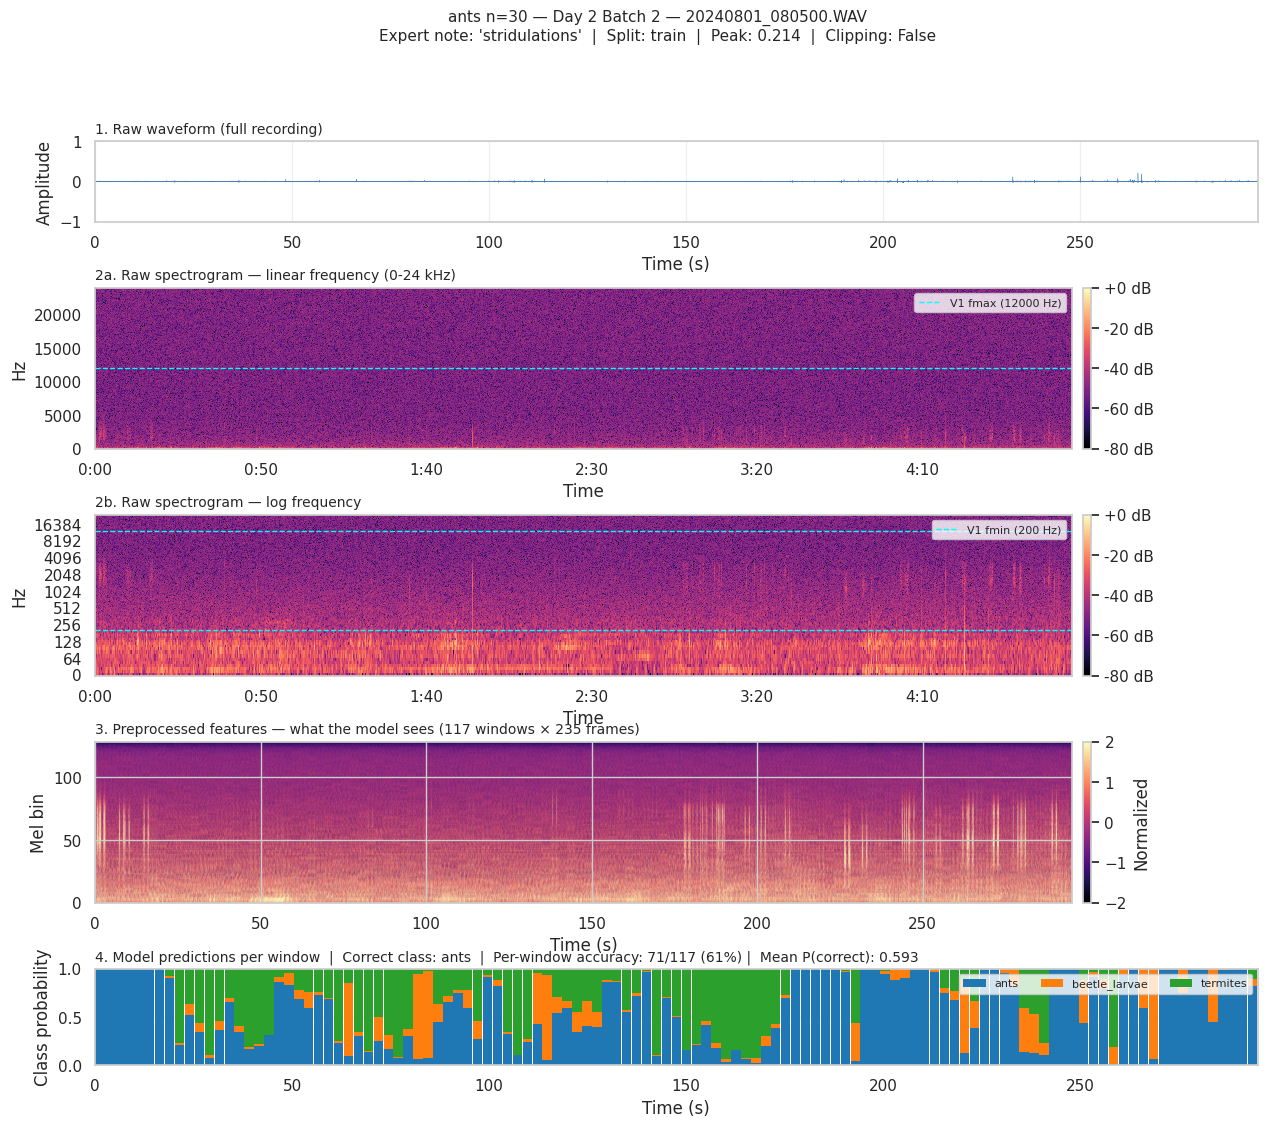

    → model classified 71/117 windows correctly (mean P(correct)=0.593)

[2/6] ants — 20240801_081000.WAV
    expert note: stridulations
  Saved: diagnostics/diag_ants_d2b2_n30_20240801_081000.png + .pdf


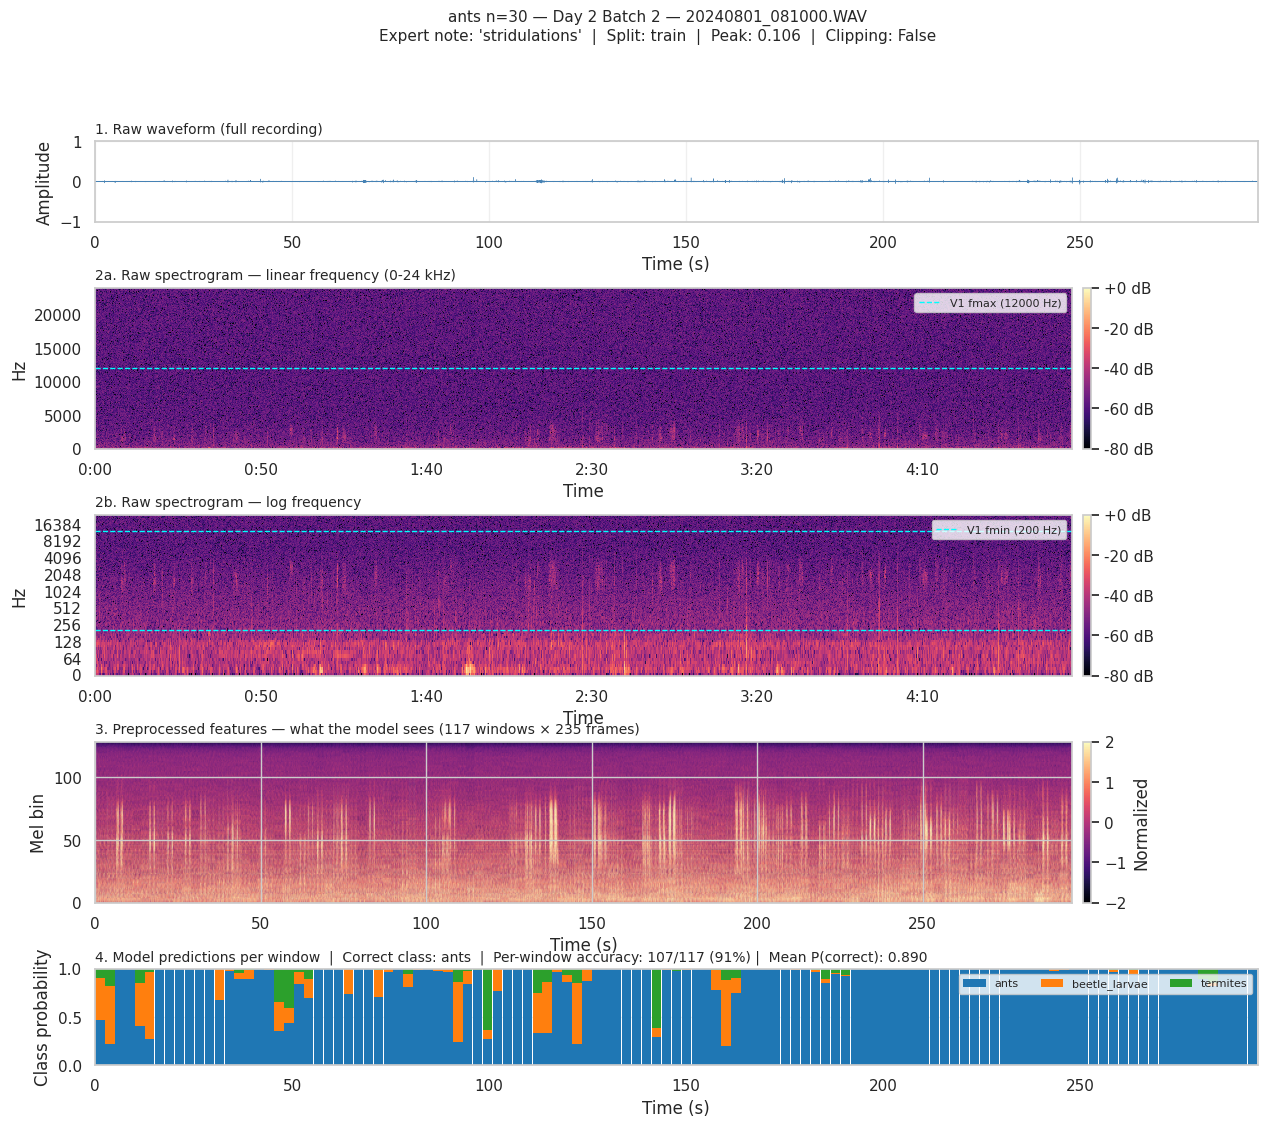

    → model classified 107/117 windows correctly (mean P(correct)=0.890)

[3/6] termites — 20240810_090000.WAV
    expert note: movement
  Saved: diagnostics/diag_termites_d5b2_n10_20240810_090000.png + .pdf


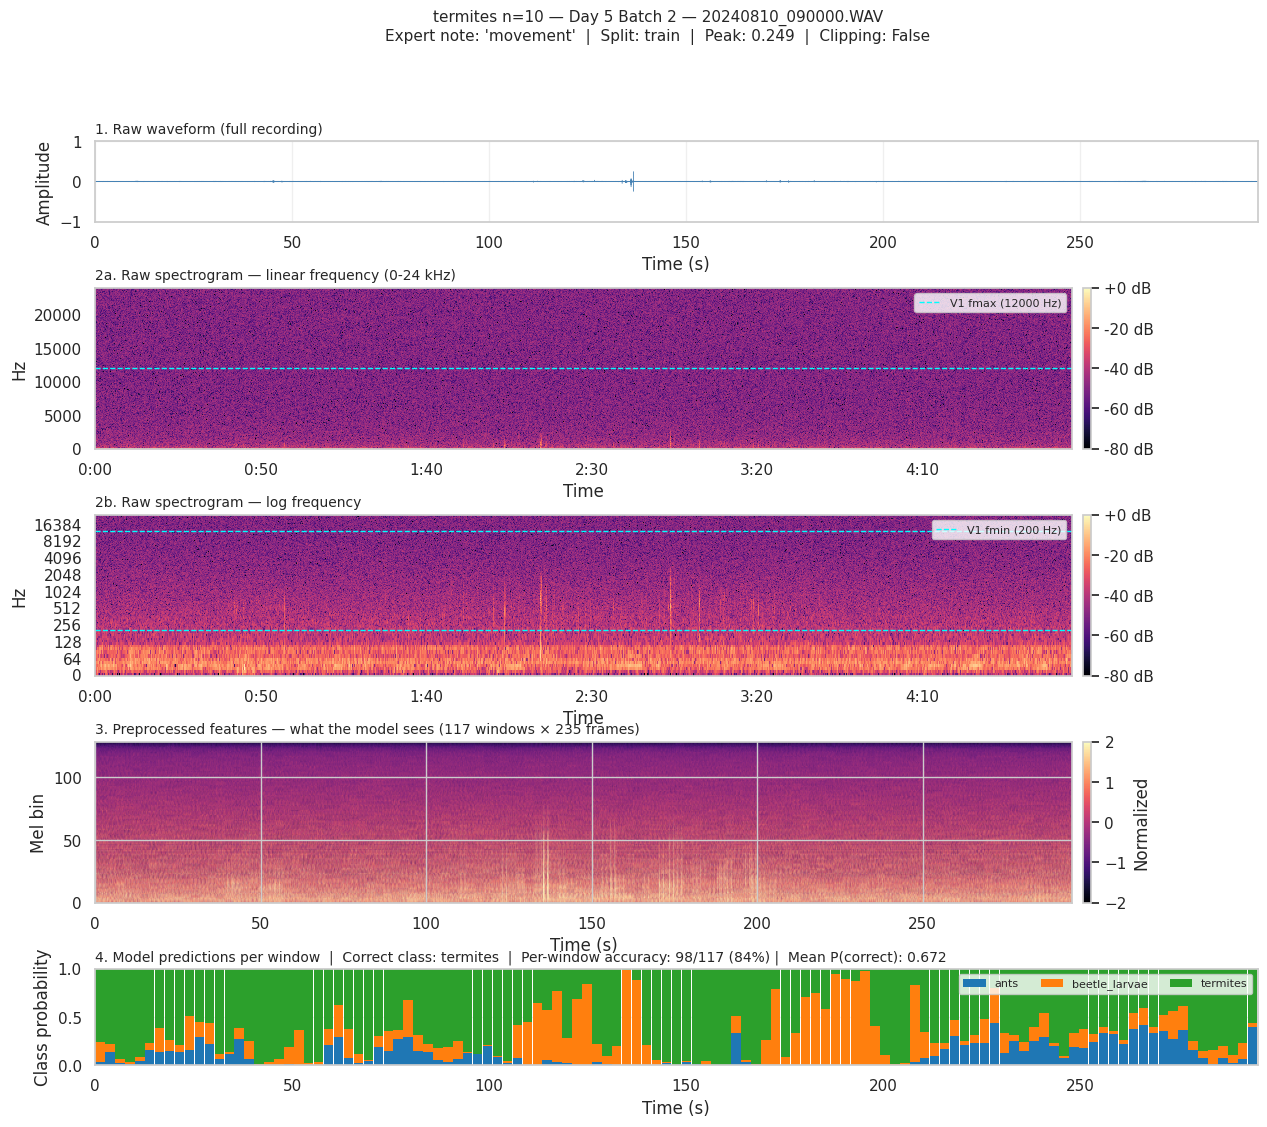

    → model classified 98/117 windows correctly (mean P(correct)=0.672)

[4/6] termites — 20240808_114000.WAV
    expert note: movement
  Saved: diagnostics/diag_termites_d4b3_n10_20240808_114000.png + .pdf


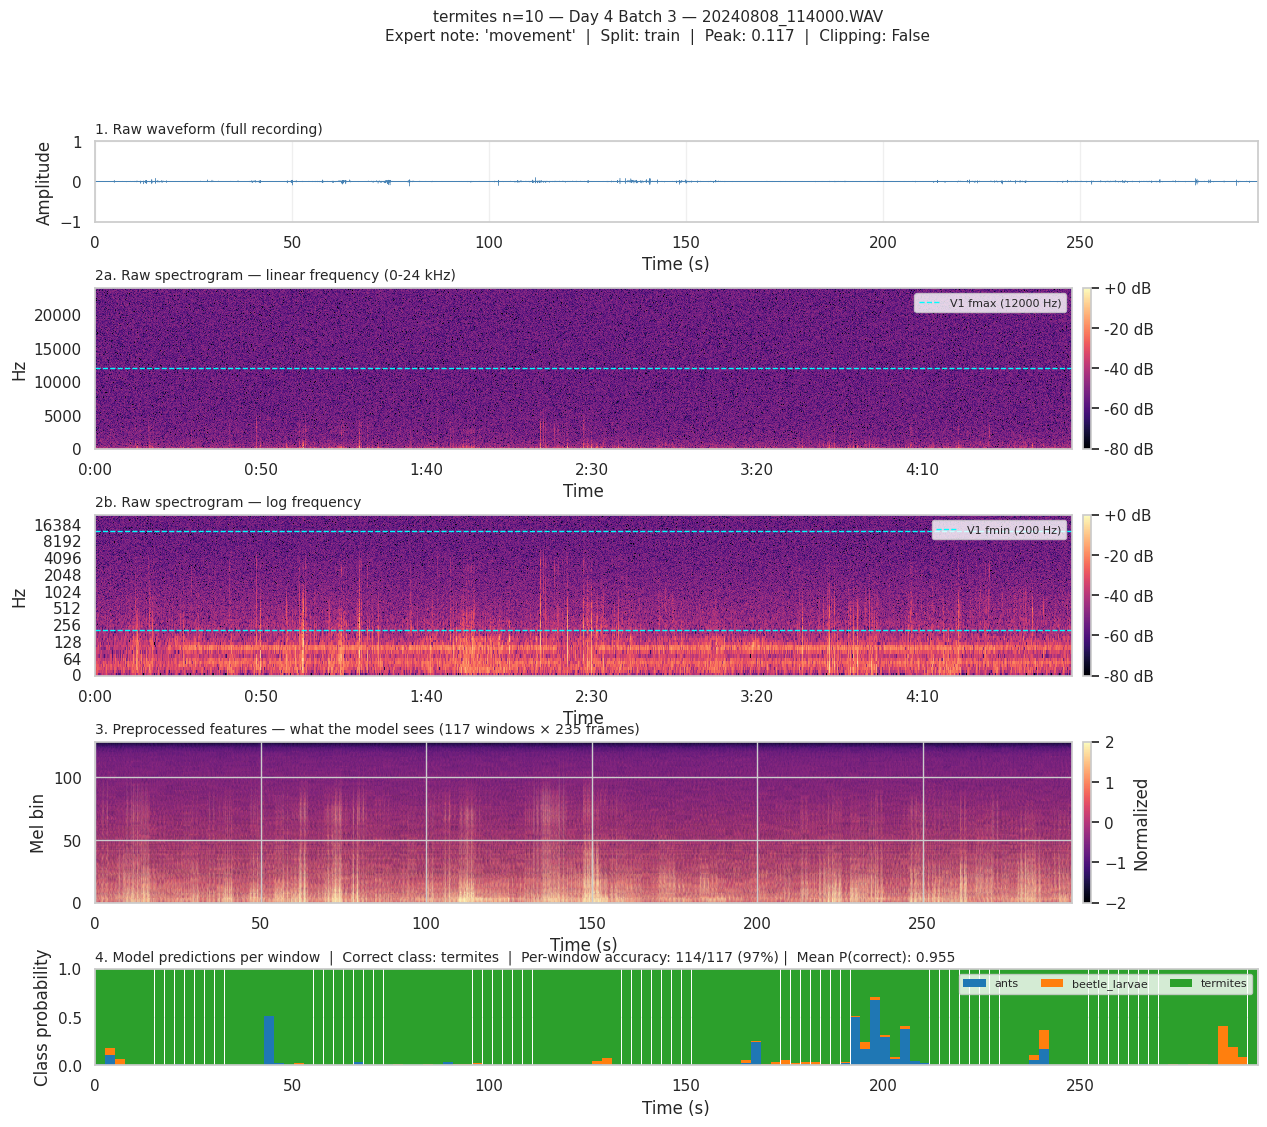

    → model classified 114/117 windows correctly (mean P(correct)=0.955)

[5/6] beetle_larvae — 20240808_075000.WAV
    expert note: movement
  Saved: diagnostics/diag_beetle_larvae_d4b2_n3_20240808_075000.png + .pdf


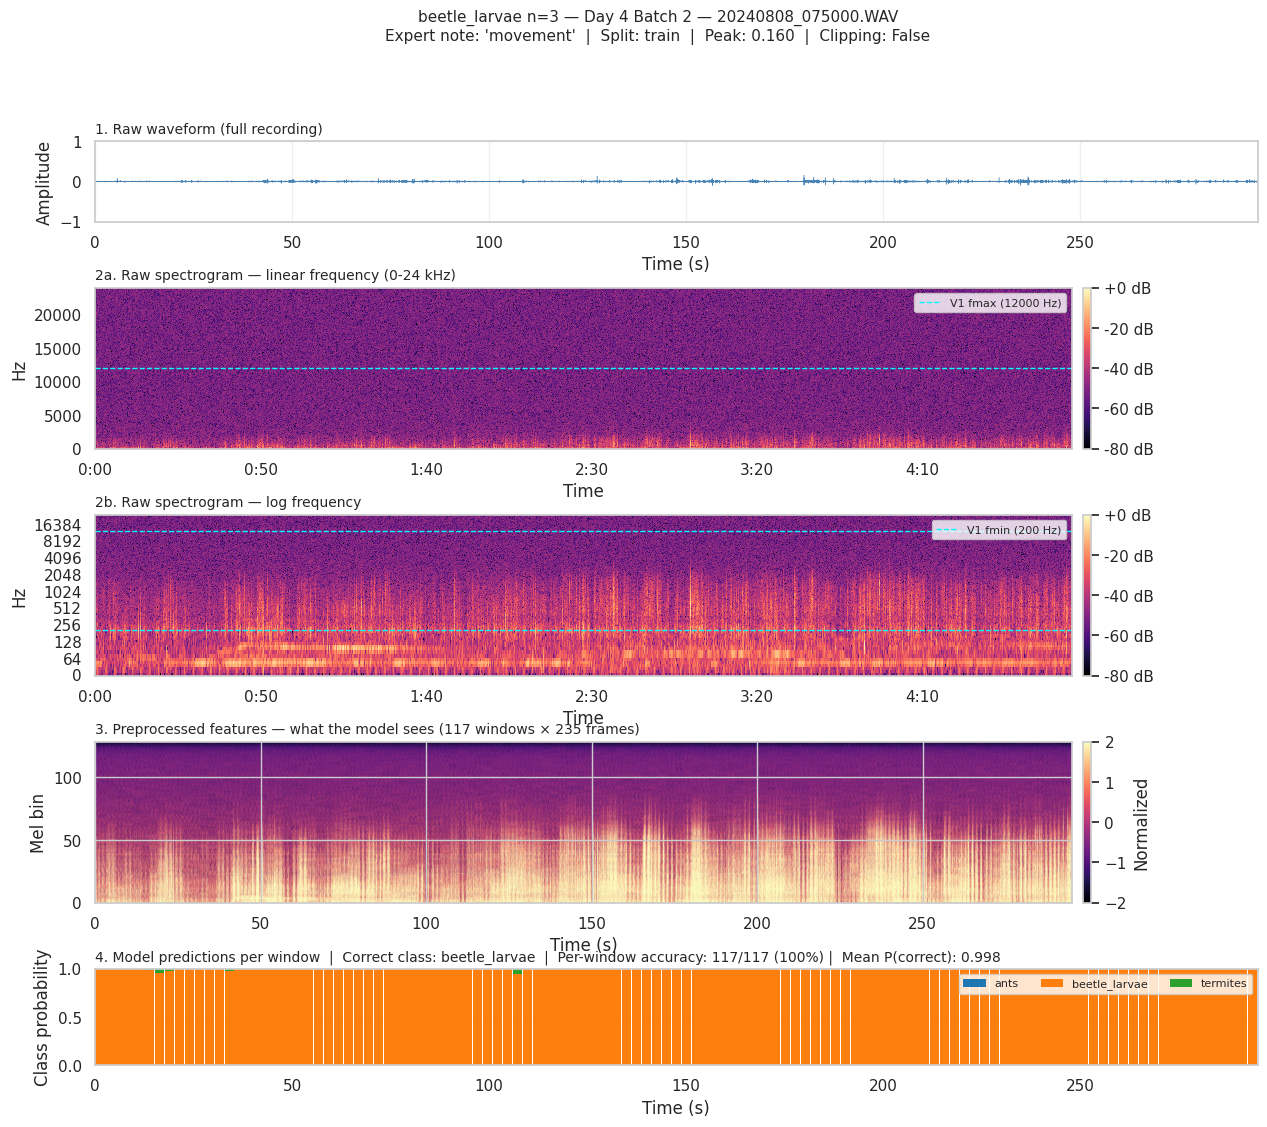

    → model classified 117/117 windows correctly (mean P(correct)=0.998)

[6/6] beetle_larvae — 20240813_091500.WAV
    expert note: movement and stridulations
  Saved: diagnostics/diag_beetle_larvae_d6b2_n3_20240813_091500.png + .pdf


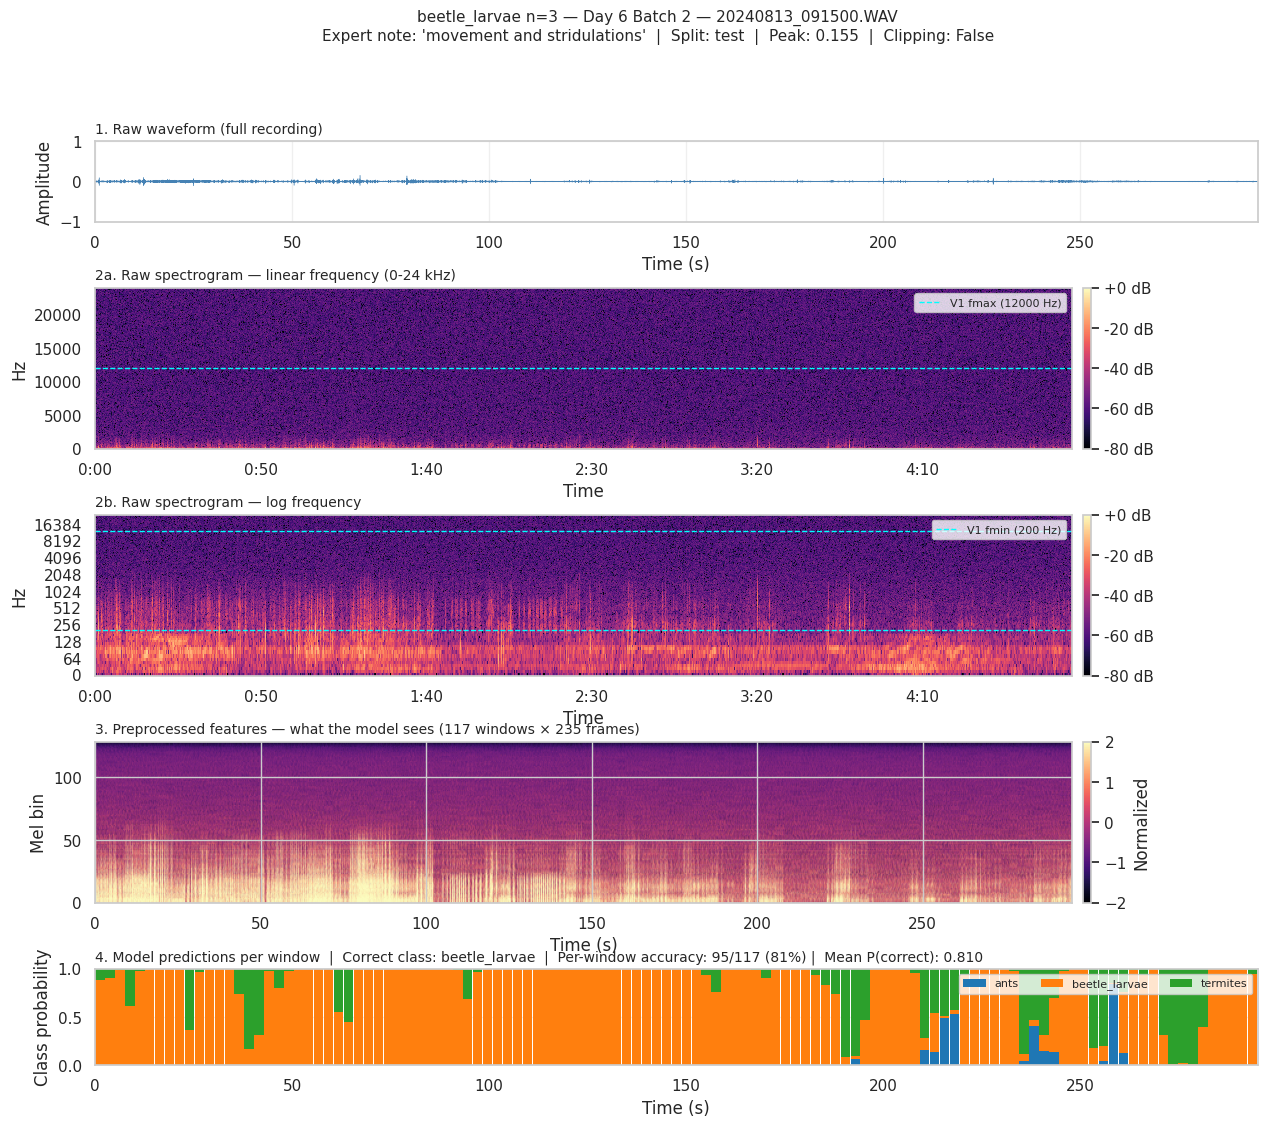

    → model classified 95/117 windows correctly (mean P(correct)=0.810)

DIAGNOSTIC SUMMARY
        taxon                file  n_windows  n_correct_windows  accuracy  mean_correct_prob  has_clipping
         ants 20240801_080500.WAV        117                 71     0.607           0.592525         False
         ants 20240801_081000.WAV        117                107     0.915           0.890148         False
     termites 20240810_090000.WAV        117                 98     0.838           0.671649         False
     termites 20240808_114000.WAV        117                114     0.974           0.955424         False
beetle_larvae 20240808_075000.WAV        117                117     1.000           0.998262         False
beetle_larvae 20240813_091500.WAV        117                 95     0.812           0.810440         False

Saved summary: /content/drive/MyDrive/Invertebrate recordings subset/v2_edgetrim/diagnostics/expert_files_summary.csv


In [ ]:
import librosa
import librosa.display
import soundfile as sf
from scipy.signal import butter, sosfiltfilt

# =============================================================================
# Define the 6 expert-flagged files
# =============================================================================
EXPERT_FILES = [
    {'taxon': 'ants', 'count': 30, 'day': 2, 'batch': 2,
     'filename': '20240801_080500.WAV', 'note': 'stridulations'},
    {'taxon': 'ants', 'count': 30, 'day': 2, 'batch': 2,
     'filename': '20240801_081000.WAV', 'note': 'stridulations'},
    {'taxon': 'termites', 'count': 10, 'day': 5, 'batch': 2,
     'filename': '20240810_090000.WAV', 'note': 'movement'},
    {'taxon': 'termites', 'count': 10, 'day': 4, 'batch': 3,
     'filename': '20240808_114000.WAV', 'note': 'movement'},
    {'taxon': 'beetle_larvae', 'count': 3, 'day': 4, 'batch': 2,
     'filename': '20240808_075000.WAV', 'note': 'movement'},
    {'taxon': 'beetle_larvae', 'count': 3, 'day': 6, 'batch': 2,
     'filename': '20240813_091500.WAV', 'note': 'movement and stridulations'},
]

# =============================================================================
# Resolve each expert file to its source path, feature file, and split assignment
# =============================================================================
expert_records = []
for ef in EXPERT_FILES:
    # Find the inventory row
    inv_match = inventory_final_df[
        (inventory_final_df['taxon'] == ef['taxon']) &
        (inventory_final_df['count'] == ef['count']) &
        (inventory_final_df['day'] == ef['day']) &
        (inventory_final_df['batch'] == ef['batch']) &
        (inventory_final_df['filename'] == ef['filename'])
    ]
    if len(inv_match) == 0:
        print(f"⚠️  NOT FOUND in inventory: {ef}")
        continue
    if len(inv_match) > 1:
        print(f"⚠️  Multiple matches for {ef['filename']} — taking first")
    inv_row = inv_match.iloc[0]

    # Find the corresponding feature file via manifest
    man_match = manifest_df[manifest_df['source_filepath'] == inv_row['filepath']]
    if len(man_match) == 0:
        print(f"⚠️  No feature file for {ef['filename']}")
        continue
    feature_filename = man_match.iloc[0]['feature_filename']

    # Find split assignment
    sess_key_match = splits_3class[
        (splits_3class['day'] == ef['day']) &
        (splits_3class['batch'] == ef['batch']) &
        (splits_3class['taxon'] == ef['taxon']) &
        (splits_3class['count'] == ef['count'])
    ]
    split_assignment = sess_key_match.iloc[0]['split'] if len(sess_key_match) > 0 else 'unknown'

    expert_records.append({
        **ef,
        'source_filepath': inv_row['filepath'],
        'feature_filename': feature_filename,
        'duration_s': inv_row['duration_s'],
        'peak_amplitude': inv_row['peak_amplitude'],
        'has_clipping': inv_row['has_clipping'],
        'is_partial': inv_row['is_partial'],
        'split': split_assignment,
    })

print(f"Resolved {len(expert_records)}/{len(EXPERT_FILES)} expert files\n")
print(f"{'Class':<15} {'File':<25} {'Split':<8} {'Dur(s)':<7} {'Peak':<7} {'Note'}")
print("-" * 95)
for r in expert_records:
    print(f"{r['taxon']:<15} {r['filename']:<25} {r['split']:<8} "
          f"{r['duration_s']:<7.1f} {r['peak_amplitude']:<7.3f} {r['note']}")
print()

# =============================================================================
# Load the frozen v1 CNN for model-response analysis
# =============================================================================
cnn_v1 = SpectrogramCNN(n_classes=3).to(device)
ckpt = torch.load(PROJECT_ROOT / 'cnn_3class_FINAL_v1.pt', map_location=device)
cnn_v1.load_state_dict(ckpt['model_state_dict'])
cnn_v1.eval()
print(f"Loaded v1 CNN (epoch {ckpt['epoch']}, val_f1 {ckpt['val_f1']:.4f})\n")

# Pipeline params for reference
BANDPASS_LOW = pipeline_params['bandpass_low_hz']
BANDPASS_HIGH = pipeline_params['bandpass_high_hz']
print(f"V1 bandpass: {BANDPASS_LOW}-{BANDPASS_HIGH} Hz\n")

# =============================================================================
# Generate diagnostic figure per file
# =============================================================================
def diagnose_file(record):
    """Generate the 3-view diagnostic figure for one recording."""

    # ---- View 1: Raw audio ----
    y_raw, sr = librosa.load(record['source_filepath'], sr=None, mono=True)
    duration = len(y_raw) / sr

    # STFT for spectrogram views (raw, no filtering)
    n_fft_diag = 4096  # higher resolution for inspection
    hop_diag = 1024
    D = librosa.stft(y_raw, n_fft=n_fft_diag, hop_length=hop_diag, window='hann')
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    # ---- View 2: Preprocessed features ----
    feat_data = np.load(V1_FEATURES_DIR / record['feature_filename'])
    features = feat_data['features']  # (n_windows, 128, 235)
    has_clip = feat_data['has_clipping']
    n_windows = len(features)

    # Stitch all windows into a single (n_mels, n_windows*235) display
    stitched = np.concatenate([features[i] for i in range(n_windows)], axis=1)

    # ---- View 3: Model predictions per window ----
    with torch.no_grad():
        X = torch.from_numpy(features[:, np.newaxis, :, :].astype(np.float32)).to(device)
        logits = cnn_v1(X)
        probs = torch.softmax(logits, dim=1).cpu().numpy()  # (n_windows, 3)
        preds = probs.argmax(axis=1)

    correct_class_idx = CLASS_TO_IDX[record['taxon']]
    n_correct = int((preds == correct_class_idx).sum())
    mean_correct_prob = float(probs[:, correct_class_idx].mean())

    # ---- Build the figure ----
    fig = plt.figure(figsize=(15, 12))
    gs = fig.add_gridspec(5, 1, height_ratios=[1, 2, 2, 2, 1.2], hspace=0.5)

    # Title
    title = (f"{record['taxon']} n={record['count']} — Day {record['day']} "
             f"Batch {record['batch']} — {record['filename']}\n"
             f"Expert note: '{record['note']}'  |  Split: {record['split']}  "
             f"|  Peak: {record['peak_amplitude']:.3f}  |  Clipping: {record['has_clipping']}")
    fig.suptitle(title, fontsize=11, y=0.99)

    # (1) Waveform
    ax_wave = fig.add_subplot(gs[0])
    times = np.arange(len(y_raw)) / sr
    ax_wave.plot(times, y_raw, linewidth=0.3, color='steelblue')
    ax_wave.set_xlim(0, duration)
    ax_wave.set_ylim(-1, 1)
    ax_wave.set_ylabel('Amplitude'); ax_wave.set_xlabel('Time (s)')
    ax_wave.set_title('1. Raw waveform (full recording)', fontsize=10, loc='left')
    ax_wave.grid(True, alpha=0.3)

    # (2) Raw linear-frequency spectrogram
    ax_spec_lin = fig.add_subplot(gs[1])
    img = librosa.display.specshow(S_db, sr=sr, hop_length=hop_diag,
                                    x_axis='time', y_axis='linear',
                                    ax=ax_spec_lin, vmin=-80, vmax=0, cmap='magma')
    ax_spec_lin.set_title('2a. Raw spectrogram — linear frequency (0-24 kHz)',
                          fontsize=10, loc='left')
    ax_spec_lin.axhline(BANDPASS_HIGH, color='cyan', linestyle='--', linewidth=1,
                        label=f'V1 fmax ({BANDPASS_HIGH} Hz)')
    ax_spec_lin.legend(loc='upper right', fontsize=8)
    fig.colorbar(img, ax=ax_spec_lin, format='%+2.0f dB', pad=0.01)

    # (3) Raw log-frequency spectrogram
    ax_spec_log = fig.add_subplot(gs[2])
    img = librosa.display.specshow(S_db, sr=sr, hop_length=hop_diag,
                                    x_axis='time', y_axis='log',
                                    ax=ax_spec_log, vmin=-80, vmax=0, cmap='magma')
    ax_spec_log.set_title('2b. Raw spectrogram — log frequency',
                          fontsize=10, loc='left')
    ax_spec_log.axhline(BANDPASS_LOW, color='cyan', linestyle='--', linewidth=1,
                        label=f'V1 fmin ({BANDPASS_LOW} Hz)')
    ax_spec_log.axhline(BANDPASS_HIGH, color='cyan', linestyle='--', linewidth=1)
    ax_spec_log.legend(loc='upper right', fontsize=8)
    fig.colorbar(img, ax=ax_spec_log, format='%+2.0f dB', pad=0.01)

    # (4) Preprocessed mel-spectrogram (what the model sees)
    ax_pre = fig.add_subplot(gs[3])
    n_time = stitched.shape[1]
    img = ax_pre.imshow(stitched, aspect='auto', origin='lower',
                        cmap='magma', vmin=-2, vmax=2,
                        extent=[0, duration, 0, 128])
    ax_pre.set_title(f'3. Preprocessed features — what the model sees '
                     f'({n_windows} windows × 235 frames)',
                     fontsize=10, loc='left')
    ax_pre.set_ylabel('Mel bin'); ax_pre.set_xlabel('Time (s)')
    fig.colorbar(img, ax=ax_pre, label='Normalized', pad=0.01)

    # (5) Model predictions over time — colored bar
    ax_pred = fig.add_subplot(gs[4])
    window_dur = duration / n_windows
    window_centers = (np.arange(n_windows) + 0.5) * window_dur

    # Probability bars per class
    bar_width = window_dur * 0.95
    colors_taxa = {'ants': '#1f77b4', 'beetle_larvae': '#ff7f0e', 'termites': '#2ca02c'}
    bottom = np.zeros(n_windows)
    for class_idx, class_name in enumerate(CLASSES_3):
        ax_pred.bar(window_centers, probs[:, class_idx], bottom=bottom,
                    width=bar_width, color=colors_taxa[class_name],
                    label=class_name, edgecolor='none')
        bottom += probs[:, class_idx]

    ax_pred.set_xlim(0, duration)
    ax_pred.set_ylim(0, 1)
    ax_pred.set_ylabel('Class probability')
    ax_pred.set_xlabel('Time (s)')
    ax_pred.set_title(f'4. Model predictions per window  |  Correct class: '
                      f'{record["taxon"]}  |  Per-window accuracy: '
                      f'{n_correct}/{n_windows} ({n_correct/n_windows:.0%}) '
                      f'|  Mean P(correct): {mean_correct_prob:.3f}',
                      fontsize=10, loc='left')
    ax_pred.legend(loc='upper right', fontsize=8, ncol=3)
    ax_pred.grid(True, alpha=0.3, axis='y')

    # Save
    save_name = (f"diag_{record['taxon']}_d{record['day']}b{record['batch']}_"
                 f"n{record['count']}_{record['filename'].replace('.WAV', '')}")
    save_v2_figure(fig, save_name, subdir='diagnostics')
    plt.show()
    plt.close(fig)

    return {
        'file': record['filename'],
        'taxon': record['taxon'],
        'n_windows': n_windows,
        'n_correct_windows': n_correct,
        'mean_correct_prob': mean_correct_prob,
        'has_clipping': record['has_clipping'],
    }

# =============================================================================
# Run diagnostic for each file
# =============================================================================
print("=" * 70)
print("Running diagnostic for each expert-flagged file")
print("=" * 70)

results = []
for i, record in enumerate(expert_records, 1):
    print(f"\n[{i}/{len(expert_records)}] {record['taxon']} — {record['filename']}")
    print(f"    expert note: {record['note']}")
    result = diagnose_file(record)
    results.append(result)
    print(f"    → model classified {result['n_correct_windows']}/{result['n_windows']} "
          f"windows correctly (mean P(correct)={result['mean_correct_prob']:.3f})")

# =============================================================================
# Summary
# =============================================================================
print("\n" + "=" * 70)
print("DIAGNOSTIC SUMMARY")
print("=" * 70)
summary_df = pd.DataFrame(results)
summary_df['accuracy'] = (summary_df['n_correct_windows'] / summary_df['n_windows']).round(3)
print(summary_df[['taxon', 'file', 'n_windows', 'n_correct_windows', 'accuracy',
                   'mean_correct_prob', 'has_clipping']].to_string(index=False))
print()

# Save summary
summary_df.to_csv(V2_DIAGNOSTICS_DIR / 'expert_files_summary.csv', index=False)
print(f"Saved summary: {V2_DIAGNOSTICS_DIR / 'expert_files_summary.csv'}")

## V2 Block 2: Apply Edge Trimming Rule (drop first 2 + last 2 per session)

**Purpose:** Update the inventory to implement the v2 trimming rule agreed with
the PhD student — drop the first two and last two files chronologically per
session, instead of just the first and last.

**Approach (metadata-only, no re-extraction):**
1. Load the v1 inventory (which already had first-1/last-1 removed, plus other
   cleaning applied — see Findings 1.3–1.6)
2. Re-derive the v2 trimming from the *original raw file list*, applying the
   drop-first-2/last-2 rule to each session
3. Combine with all other v1 cleaning rules (short-file drops, partial-file
   flagging) so we don't lose those decisions
4. Produce v2 inventory, features manifest, and PANNs manifest — all as
   filtered subsets of v1

**Why not re-extract features:** Feature computation is unchanged; only file
selection differs. Existing .npz files for retained files remain valid.
The v2 manifests point at the same feature files but exclude the newly-trimmed
ones.

**Sanity checks included:**
- Per-session before/after file counts
- Per-taxon totals before/after
- Verify no session drops below a minimum viable file count
- Verify Day 3 Batch 4 (the anomalous extended session) is handled sensibly

**Outputs (all in v2_edgetrim/):**
- `inventory_v2.csv` — v2 file inventory
- `features_manifest_v2.csv` — v2 features manifest
- `panns_embeddings_manifest_v2.csv` — v2 PANNs manifest
- `edge_trim_report_v2.csv` — per-session before/after summary

In [ ]:
# =============================================================================
# V2 Block 2: Apply drop-first-2 / last-2 edge trimming
# =============================================================================
print("=" * 70)
print("V2 Block 2: Apply edge trimming (drop first 2 + last 2 per session)")
print("=" * 70)

# =============================================================================
# Step 1: Load v1 inventory and identify what v1 kept vs what was dropped
# =============================================================================
# The v1 inventory has ALL cleaning already applied (first/last drop,
# short-duration drop). We need to re-derive from a more complete list to
# apply the v2 rule from scratch, then re-apply the OTHER cleaning rules.
#
# Simplest approach: take the v1 kept files, group by session, then within
# each session drop the 1 earliest and 1 latest chronologically. This gives
# the v2 trim relative to what v1 kept, achieving the "drop first 2 + last 2
# from raw" effect (since v1 already dropped first 1 + last 1).

print("Loading v1 inventory...")
inv_v1 = inventory_final_df.copy()
print(f"  v1 inventory: {len(inv_v1)} files")
print()

# Parse timestamp from filename for chronological ordering within session
def parse_timestamp_from_filename(filename):
    # Format: YYYYMMDD_HHMMSS.WAV
    base = filename.replace('.WAV', '').replace('.wav', '')
    return pd.to_datetime(base, format='%Y%m%d_%H%M%S', errors='coerce')

inv_v1['timestamp'] = inv_v1['filename'].apply(parse_timestamp_from_filename)
n_bad_ts = inv_v1['timestamp'].isna().sum()
if n_bad_ts > 0:
    print(f"⚠️  {n_bad_ts} files had unparseable timestamps — dropping from v2")
    inv_v1 = inv_v1[inv_v1['timestamp'].notna()].copy()

# =============================================================================
# Step 2: Group by session and apply the additional-1 drop from each end
# =============================================================================
# Session identity: (day, batch, taxon, count, replicate_id)
session_keys = ['day', 'batch', 'taxon', 'count', 'replicate_id']

session_reports = []
kept_indices = []

for session_id, session_df in inv_v1.groupby(session_keys):
    session_df_sorted = session_df.sort_values('timestamp').reset_index(drop=False)
    n_files = len(session_df_sorted)

    # v1 already dropped 1 from each end. v2 drops one MORE from each end.
    # If session has <= 2 files after v1, dropping more would empty it.
    if n_files <= 2:
        kept_in_session = []
        reason = 'session too small after v1 trimming'
    else:
        # Keep everything except the first 1 and last 1 of the v1-kept files
        kept_in_session = session_df_sorted.iloc[1:-1]['index'].tolist()
        reason = None

    kept_indices.extend(kept_in_session)
    session_reports.append({
        **dict(zip(session_keys, session_id)),
        'n_files_v1': n_files,
        'n_files_v2': len(kept_in_session),
        'n_dropped_v2_only': n_files - len(kept_in_session),
        'note': reason,
    })

# Build v2 inventory
inv_v2 = inv_v1.loc[kept_indices].copy().sort_values(
    session_keys + ['timestamp']).reset_index(drop=True)
inv_v2 = inv_v2.drop(columns=['timestamp'])

print(f"v2 inventory: {len(inv_v2)} files (vs {len(inv_v1)} in v1)")
print(f"Additional files removed by v2 rule: {len(inv_v1) - len(inv_v2)}")
print()

# =============================================================================
# Step 3: Sanity checks
# =============================================================================
report_df = pd.DataFrame(session_reports)

print("=" * 70)
print("Sanity check: Per-session before/after")
print("=" * 70)

# Any session that lost too many files?
tiny_sessions = report_df[report_df['n_files_v2'] < 5]
if len(tiny_sessions) > 0:
    print(f"⚠️  {len(tiny_sessions)} sessions have < 5 files after v2 trimming:")
    print(tiny_sessions.to_string(index=False))
    print()

# Anomalous session check
day3_b4 = report_df[(report_df['day'] == 3) & (report_df['batch'] == 4)]
if len(day3_b4) > 0:
    print("Day 3 Batch 4 (previously flagged anomalous extended session):")
    print(day3_b4.to_string(index=False))
    print()

# Per-taxon totals
print("Per-taxon file counts, v1 vs v2:")
comparison = pd.DataFrame({
    'v1': inv_v1['taxon'].value_counts().sort_index(),
    'v2': inv_v2['taxon'].value_counts().sort_index(),
})
comparison['dropped_v2'] = comparison['v1'] - comparison['v2']
comparison['pct_dropped_v2'] = (comparison['dropped_v2'] / comparison['v1'] * 100).round(1)
print(comparison)
print()

# =============================================================================
# Step 4: Derive v2 features manifest
# =============================================================================
# Keep only manifest rows whose source_filepath survives in v2 inventory
v2_source_paths = set(inv_v2['filepath'].tolist())
manifest_v2 = manifest_df[manifest_df['source_filepath'].isin(v2_source_paths)].copy()
manifest_v2 = manifest_v2.reset_index(drop=True)
print(f"v2 features manifest: {len(manifest_v2)} recordings (vs {len(manifest_df)} in v1)")

# Verify total windows change
n_windows_v1 = manifest_df['n_windows'].sum()
n_windows_v2 = manifest_v2['n_windows'].sum()
print(f"v2 total windows: {n_windows_v2:,} (vs {n_windows_v1:,} in v1, "
      f"−{n_windows_v1 - n_windows_v2:,} = −{(n_windows_v1-n_windows_v2)/n_windows_v1*100:.1f}%)")
print()

# =============================================================================
# Step 5: Derive v2 PANNs manifest
# =============================================================================
panns_manifest_v1 = pd.read_csv(PROJECT_ROOT / 'panns_embeddings_manifest.csv')
panns_manifest_v2 = panns_manifest_v1[
    panns_manifest_v1['source_filepath'].isin(v2_source_paths)].copy()
panns_manifest_v2 = panns_manifest_v2.reset_index(drop=True)
print(f"v2 PANNs manifest: {len(panns_manifest_v2)} recordings")
print()

# =============================================================================
# Step 6: Save outputs
# =============================================================================
inv_v2_path = V2_ROOT / 'inventory_v2.csv'
manifest_v2_path = V2_ROOT / 'features_manifest_v2.csv'
panns_manifest_v2_path = V2_ROOT / 'panns_embeddings_manifest_v2.csv'
report_path = V2_ROOT / 'edge_trim_report_v2.csv'

inv_v2.to_csv(inv_v2_path, index=False)
manifest_v2.to_csv(manifest_v2_path, index=False)
panns_manifest_v2.to_csv(panns_manifest_v2_path, index=False)
report_df.to_csv(report_path, index=False)

print("=" * 70)
print("V2 Block 2 complete — outputs saved:")
print("=" * 70)
print(f"  {inv_v2_path.name}: {len(inv_v2)} files")
print(f"  {manifest_v2_path.name}: {len(manifest_v2)} recordings")
print(f"  {panns_manifest_v2_path.name}: {len(panns_manifest_v2)} recordings")
print(f"  {report_path.name}: {len(report_df)} sessions")

V2 Block 2: Apply edge trimming (drop first 2 + last 2 per session)
Loading v1 inventory...
  v1 inventory: 1801 files

v2 inventory: 1657 files (vs 1801 in v1)
Additional files removed by v2 rule: 144

Sanity check: Per-session before/after
Day 3 Batch 4 (previously flagged anomalous extended session):
 day  batch         taxon  count  replicate_id  n_files_v1  n_files_v2  n_dropped_v2_only note
   3      4          ants     10             1          45          43                  2 None
   3      4 beetle_larvae      3             1          45          43                  2 None
   3      4       control      0             1          45          43                  2 None

Per-taxon file counts, v1 vs v2:
                v1   v2  dropped_v2  pct_dropped_v2
taxon                                              
ants           519  477          42             8.1
beetle_larvae  520  480          40             7.7
control        259  239          20             7.7
termites       503  4

## V2 Block 3: Generate v2 Splits (Preserving v1 Session Assignments)

**Purpose:** Create train/val/test splits for the v2 inventory that preserve
the session-level split assignments from v1. This isolates the effect of edge
trimming: v1 vs v2 comparison uses the same validation sessions, just with
2 fewer files per session.

**Approach:** Inherit split labels from v1 splits_3class.csv and splits_4class.csv,
apply to the v2 inventory. No re-stratification needed; the session-level
splits are already balanced.

**Why not re-stratify:** Regenerating splits from scratch (even with the same
seed) could put different sessions in train/val/test, making v1 vs v2
comparison confounded by different validation sessions. Preserving v1
assignments makes the comparison clean.

**Outputs:**
- `splits_3class_v2.csv`
- `splits_4class_v2.csv`
- Summary printout of file counts per split

In [ ]:
# =============================================================================
# V2 Block 3: Generate v2 splits by inheriting v1 session assignments
# =============================================================================
print("=" * 70)
print("V2 Block 3: Generate v2 splits (inherit v1 session assignments)")
print("=" * 70)

# =============================================================================
# Step 1: Load v1 splits and v2 inventory
# =============================================================================
splits_3_v1 = pd.read_csv(PROJECT_ROOT / 'splits_3class.csv')
splits_4_v1 = pd.read_csv(PROJECT_ROOT / 'splits_4class.csv')
inv_v2 = pd.read_csv(V2_ROOT / 'inventory_v2.csv')

session_keys = ['day', 'batch', 'taxon', 'count', 'replicate_id']

print(f"v1 splits_3class: {len(splits_3_v1)} sessions")
print(f"v1 splits_4class: {len(splits_4_v1)} sessions")
print(f"v2 inventory: {len(inv_v2)} files")
print()

# =============================================================================
# Step 2: Identify v2 sessions (any session with at least 1 file in v2)
# =============================================================================
v2_sessions = inv_v2.groupby(session_keys).size().reset_index(name='n_files_v2')
print(f"v2 sessions (with at least 1 file): {len(v2_sessions)}")

# =============================================================================
# Step 3: 3-class splits — inherit assignments
# =============================================================================
print()
print("=" * 70)
print("3-class splits")
print("=" * 70)

splits_3_v2 = v2_sessions.merge(splits_3_v1[session_keys + ['split']],
                                  on=session_keys, how='inner')
# 3-class excludes control
splits_3_v2 = splits_3_v2[splits_3_v2['taxon'] != 'control'].reset_index(drop=True)

# Check: any v1 3-class session missing from v2?
v1_3class_sessions = set(splits_3_v1.apply(
    lambda r: tuple(r[k] for k in session_keys), axis=1))
v2_sessions_set = set(v2_sessions.apply(
    lambda r: tuple(r[k] for k in session_keys), axis=1))
missing_3 = v1_3class_sessions - v2_sessions_set
if missing_3:
    print(f"⚠️  {len(missing_3)} v1 3-class sessions have no files in v2:")
    for s in missing_3:
        print(f"    {dict(zip(session_keys, s))}")
else:
    print("✓ All v1 3-class sessions retained in v2")
print()

# File counts per split
files_per_split_3 = inv_v2.merge(splits_3_v2[session_keys + ['split']],
                                   on=session_keys, how='inner')
print("v2 3-class file counts per split:")
split_summary_3 = files_per_split_3.groupby(['split', 'taxon']).size().unstack(fill_value=0)
split_summary_3['total'] = split_summary_3.sum(axis=1)
print(split_summary_3)
print()

# =============================================================================
# Step 4: 4-class splits — inherit assignments
# =============================================================================
print("=" * 70)
print("4-class splits")
print("=" * 70)

splits_4_v2 = v2_sessions.merge(splits_4_v1[session_keys + ['split']],
                                  on=session_keys, how='inner').reset_index(drop=True)

files_per_split_4 = inv_v2.merge(splits_4_v2[session_keys + ['split']],
                                   on=session_keys, how='inner')
print("v2 4-class file counts per split:")
split_summary_4 = files_per_split_4.groupby(['split', 'taxon']).size().unstack(fill_value=0)
split_summary_4['total'] = split_summary_4.sum(axis=1)
print(split_summary_4)
print()

# =============================================================================
# Step 5: Save v2 splits
# =============================================================================
splits_3_v2.to_csv(V2_ROOT / 'splits_3class_v2.csv', index=False)
splits_4_v2.to_csv(V2_ROOT / 'splits_4class_v2.csv', index=False)

print("Saved:")
print(f"  {V2_ROOT / 'splits_3class_v2.csv'}: {len(splits_3_v2)} sessions")
print(f"  {V2_ROOT / 'splits_4class_v2.csv'}: {len(splits_4_v2)} sessions")

# =============================================================================
# Comparison to v1 file counts
# =============================================================================
print()
print("=" * 70)
print("Comparison: v1 vs v2 file counts per split (3-class)")
print("=" * 70)

v1_3class_files = manifest_df.merge(splits_3_v1, on=session_keys, how='inner')
v1_split_counts = v1_3class_files.groupby('split').size()
v2_split_counts = files_per_split_3.groupby('split').size()

cmp = pd.DataFrame({'v1': v1_split_counts, 'v2': v2_split_counts})
cmp['dropped'] = cmp['v1'] - cmp['v2']
cmp['pct_dropped'] = (cmp['dropped'] / cmp['v1'] * 100).round(1)
print(cmp)

V2 Block 3: Generate v2 splits (inherit v1 session assignments)
v1 splits_3class: 62 sessions
v1 splits_4class: 72 sessions
v2 inventory: 1657 files

v2 sessions (with at least 1 file): 72

3-class splits
✓ All v1 3-class sessions retained in v2

v2 3-class file counts per split:
taxon  ants  beetle_larvae  termites  total
split                                      
test    109            100        56    265
train   304            291       337    932
val      64             89        68    221

4-class splits
v2 4-class file counts per split:
taxon  ants  beetle_larvae  control  termites  total
split                                               
test    109            100       23        56    288
train   304            291      194       337   1126
val      64             89       22        68    243

Saved:
  /content/drive/MyDrive/Invertebrate recordings subset/v2_edgetrim/splits_3class_v2.csv: 62 sessions
  /content/drive/MyDrive/Invertebrate recordings subset/v2_edgetrim/splits

## V2 Block 4: Retrain Custom CNN on v2 Edge-Trimmed Data

**Purpose:** Train the same VGG-style CNN architecture as v1, on the v2
edge-trimmed data, to produce a v2 benchmark comparable to v1.

**What differs from v1 (Block 18b):**
- Training data: v2 subset (932 train / 221 val recordings, ~7.6% smaller
  than v1)
- Output paths: all v2 outputs go to `v2_edgetrim/`
- Model checkpoints named `cnn_3class_best_v2.pt` and
  `cnn_3class_history_v2.json`

**What stays the same as v1:**
- Architecture: VGG-style CNN, 4 conv blocks (32/64/128/256), GAP,
  Dropout(0.5), Linear head. 1,174,371 parameters.
- Hyperparameters: Adam lr=1e-3, class weights, batch size 64, ReduceLROnPlateau,
  early stopping patience 8, max 50 epochs.
- Random seed 42 for reproducibility.
- Session-level splits (inherited from v1 for direct comparison).

**Expected runtime:** ~1.5 hours (24 epochs × ~7 min each is typical based on
v1 experience; may stop earlier due to early stopping).

**Prerequisites:**
- High-RAM runtime (~51 GB) — confirmed above
- v2 setup cell already run this session
- V2 Blocks 2 and 3 already run (v2 manifest and splits exist)

In [ ]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import psutil

# =============================================================================
# Step 1: Setup and RAM sanity check
# =============================================================================
print("=" * 70)
print("V2 Block 4: Retrain CNN on v2 edge-trimmed data")
print("=" * 70)

torch.manual_seed(42)
np.random.seed(42)

ram_available_gb = psutil.virtual_memory().available / 1e9
print(f"RAM available: {ram_available_gb:.1f} GB")
if ram_available_gb < 30:
    print("⚠️  Low RAM — this will likely OOM during preload. Switch to High-RAM runtime.")
    raise RuntimeError("Insufficient RAM for v2 preload")

# Load v2 manifest and splits
manifest_v2 = pd.read_csv(V2_ROOT / 'features_manifest_v2.csv')
splits_3_v2 = pd.read_csv(V2_ROOT / 'splits_3class_v2.csv')

print(f"v2 manifest: {len(manifest_v2)} recordings")
print(f"v2 splits: {len(splits_3_v2)} sessions")
print()

# =============================================================================
# Step 2: Preload v2 features into RAM
# =============================================================================
def preload_split_v2(split_name):
    session_keys = ['day', 'batch', 'taxon', 'count', 'replicate_id']
    split_sessions = splits_3_v2[splits_3_v2['split'] == split_name]
    split_files = manifest_v2.merge(
        split_sessions[session_keys], on=session_keys, how='inner')

    total_windows = int(split_files['n_windows'].sum())
    print(f"  {split_name}: {len(split_files)} recordings, {total_windows:,} windows")

    X = np.empty((total_windows, 128, 235), dtype=np.float32)
    y = np.empty(total_windows, dtype=np.int64)

    idx = 0
    for _, row in tqdm(split_files.iterrows(), total=len(split_files),
                        desc=f"    {split_name}", leave=False):
        # Note: v2 uses the SAME feature files as v1 (V1_FEATURES_DIR)
        # only the file selection differs
        data = np.load(V1_FEATURES_DIR / row['feature_filename'])
        features = data['features']
        n = features.shape[0]
        X[idx:idx+n] = features
        y[idx:idx+n] = CLASS_TO_IDX[row['taxon']]
        idx += n

    assert idx == total_windows, f"Window count mismatch: {idx} vs {total_windows}"
    print(f"    → X shape {X.shape}, size {X.nbytes/1e9:.2f} GB")
    return X, y

print("Preloading v2 training features into RAM...")
X_train, y_train = preload_split_v2('train')

print("\nPreloading v2 validation features into RAM...")
X_val, y_val = preload_split_v2('val')

print()
print(f"RAM after preload: {psutil.virtual_memory().used / 1e9:.1f} GB used, "
      f"{psutil.virtual_memory().available / 1e9:.1f} GB available")

V2 Block 4: Retrain CNN on v2 edge-trimmed data
RAM available: 39.2 GB
v2 manifest: 1657 recordings
v2 splits: 62 sessions

Preloading v2 training features into RAM...
  train: 932 recordings, 108,867 windows


    → X shape (108867, 128, 235), size 13.10 GB

Preloading v2 validation features into RAM...
  val: 221 recordings, 25,857 windows


    → X shape (25857, 128, 235), size 3.11 GB

RAM after preload: 31.2 GB used, 22.9 GB available


In [ ]:
# =============================================================================
# Step 3: In-memory Dataset (identical to Block 18b)
# =============================================================================
class InMemoryWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx][np.newaxis]), int(self.y[idx])

train_dataset = InMemoryWindowDataset(X_train, y_train)
val_dataset = InMemoryWindowDataset(X_val, y_val)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

# Class weights
class_weights = compute_class_weight('balanced', classes=np.arange(len(CLASSES_3)), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights: {dict(zip(CLASSES_3, class_weights.round(4)))}")
print()

# =============================================================================
# Step 4: Model (identical to v1)
# =============================================================================
model = SpectrogramCNN(n_classes=3).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print()

# =============================================================================
# Step 5: Training loop (identical to Block 18b)
# =============================================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for inputs, labels in tqdm(loader, desc='Train', leave=False):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (total_loss / len(loader),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='macro'))

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    for inputs, labels in tqdm(loader, desc='Val', leave=False):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(inputs)
        total_loss += criterion(outputs, labels).item()
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (total_loss / len(loader),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='macro'),
            all_preds, all_labels)

LEARNING_RATE = 1e-3
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8
LR_SCHEDULER_PATIENCE = 4

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                                patience=LR_SCHEDULER_PATIENCE)

V2_MODEL_PATH = V2_ROOT / 'cnn_3class_best_v2.pt'
V2_HISTORY_PATH = V2_ROOT / 'cnn_3class_history_v2.json'

best_val_f1 = -1
epochs_without_improvement = 0
history = []

print("=" * 70)
print("Training v2 CNN")
print("=" * 70)
print(f"Max epochs: {MAX_EPOCHS}, batch size: {BATCH_SIZE}, "
      f"early stopping patience: {EARLY_STOPPING_PATIENCE}")
print()

train_start = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.time()
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, device)

    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start

    history.append({
        'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
        'train_f1': train_f1, 'val_loss': val_loss, 'val_acc': val_acc,
        'val_f1': val_f1, 'lr': current_lr, 'time_s': epoch_time,
    })

    print(f"Epoch {epoch:3d}  "
          f"train_loss={train_loss:.4f} train_f1={train_f1:.4f}  "
          f"val_loss={val_loss:.4f} val_f1={val_f1:.4f}  "
          f"lr={current_lr:.1e}  ({epoch_time:.0f}s)")

    scheduler.step(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_f1': val_f1,
            'val_acc': val_acc,
        }, V2_MODEL_PATH)
        print(f"           → saved best v2 model (val_f1={val_f1:.4f})")
    else:
        epochs_without_improvement += 1

    with open(V2_HISTORY_PATH, 'w') as f:
        json.dump(history, f, indent=2)

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered.")
        break

total_time = time.time() - train_start
print(f"\nTotal training time: {total_time/60:.1f} minutes")
print(f"Best v2 validation macro-F1: {best_val_f1:.4f}")
print(f"(Compare to v1 benchmark: {cnn_v1_benchmark['recording_level_meanprob']['macro_f1']:.4f} "
      f"recording-level macro-F1)")

Train batches: 1701  |  Val batches: 405
Class weights: {'ants': np.float64(1.0203), 'beetle_larvae': np.float64(1.0659), 'termites': np.float64(0.9245)}

Model parameters: 1,174,371

Training v2 CNN
Max epochs: 50, batch size: 64, early stopping patience: 8



Epoch   1  train_loss=0.8973 train_f1=0.5508  val_loss=1.0534 val_f1=0.5524  lr=1.0e-03  (445s)
           → saved best v2 model (val_f1=0.5524)


Epoch   2  train_loss=0.7970 train_f1=0.6186  val_loss=1.0746 val_f1=0.4495  lr=1.0e-03  (447s)


Epoch   3  train_loss=0.7456 train_f1=0.6474  val_loss=1.1454 val_f1=0.5015  lr=1.0e-03  (447s)


Epoch   4  train_loss=0.7051 train_f1=0.6696  val_loss=1.0970 val_f1=0.4952  lr=1.0e-03  (445s)


...

Epoch   9  train_loss=0.6065 train_f1=0.7214  val_loss=1.1945 val_f1=0.6183  lr=1.0e-03  (448s)


Epoch  10  train_loss=0.5947 train_f1=0.7257  val_loss=0.9860 val_f1=0.5705  lr=1.0e-03  (448s)


Epoch  11  train_loss=0.5591 train_f1=0.7453  val_loss=1.0426 val_f1=0.6081  lr=5.0e-04  (447s)


Epoch  12  train_loss=0.5456 train_f1=0.7511  val_loss=1.0789 val_f1=0.5743  lr=5.0e-04  (449s)


Epoch  13  train_loss=0.5361 train_f1=0.7566  val_loss=1.2344 val_f1=0.5288  lr=5.0e-04  (447s)

Early stopping triggered.

Total training time: 96.9 minutes
Best v2 validation macro-F1: 0.6510
(Compare to v1 benchmark: 0.7490 recording-level macro-F1)


## V2 Block 5: Freeze v2 CNN and Produce Definitive v1 vs v2 Comparison

**Purpose:** Freeze the v2 best checkpoint under a versioned filename, produce
the definitive v2 metrics (window / recording / session level), and compare
head-to-head against the v1 benchmark.

**Method:**
1. Load v2 best checkpoint from V2 Block 4 training
2. Run inference on v2 validation set with source tracking
3. Aggregate at window / recording / session levels (mean-probability)
4. Compute per-class recording-level metrics and confusion matrix
5. Freeze model as `cnn_3class_FINAL_v2.pt`
6. Save `cnn_3class_FINAL_v2_metrics.json` with all metrics
7. Print head-to-head comparison table against v1

**Critical:** v1 and v2 use inherited session-level splits, so validation
sessions are the same in both. Difference in metrics reflects only the
edge-trimming change, not different validation data.

In [ ]:
import shutil
from collections import Counter

# =============================================================================
# Step 1: Load v2 best checkpoint
# =============================================================================
print("=" * 70)
print("V2 Block 5: Freeze v2 CNN and compare to v1 benchmark")
print("=" * 70)

V2_MODEL_BEST = V2_ROOT / 'cnn_3class_best_v2.pt'
checkpoint = torch.load(V2_MODEL_BEST, map_location=device)
print(f"v2 best model:")
print(f"  Epoch: {checkpoint['epoch']}")
print(f"  Val macro-F1: {checkpoint['val_f1']:.4f} (window-level, from training)")
print()

model = SpectrogramCNN(n_classes=3).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# =============================================================================
# Step 2: Inference on v2 validation with source tracking
# =============================================================================
manifest_v2 = pd.read_csv(V2_ROOT / 'features_manifest_v2.csv')
splits_3_v2 = pd.read_csv(V2_ROOT / 'splits_3class_v2.csv')
session_keys = ['day', 'batch', 'taxon', 'count', 'replicate_id']

val_sessions_v2 = splits_3_v2[splits_3_v2['split'] == 'val']
val_files_v2 = manifest_v2.merge(val_sessions_v2[session_keys],
                                   on=session_keys, how='inner')
print(f"v2 validation files: {len(val_files_v2)}")

prob_cols = ['prob_ants', 'prob_beetle_larvae', 'prob_termites']
records = []
with torch.no_grad():
    for _, row in tqdm(val_files_v2.iterrows(), total=len(val_files_v2),
                        desc="Inference"):
        data = np.load(V1_FEATURES_DIR / row['feature_filename'])
        features = data['features']
        X = torch.from_numpy(features[:, np.newaxis, :, :].astype(np.float32)).to(device)
        probs = torch.softmax(model(X), dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        for w in range(len(features)):
            records.append({
                'recording_id': row['feature_filename'],
                'session_id': (f"d{row['day']}_b{row['batch']}_{row['taxon']}"
                                f"_n{row['count']}_rep{row['replicate_id']}"),
                'true_label': CLASS_TO_IDX[row['taxon']],
                'pred_label': int(preds[w]),
                'prob_ants': probs[w, 0],
                'prob_beetle_larvae': probs[w, 1],
                'prob_termites': probs[w, 2],
            })
window_df = pd.DataFrame(records)

# =============================================================================
# Step 3: Metrics at three levels
# =============================================================================
def aggregate_meanprob(window_df, group_col):
    rows = []
    for gid, g in window_df.groupby(group_col):
        mean_probs = g[prob_cols].mean().values
        rows.append({'true_label': g['true_label'].iloc[0],
                     'pred_label': int(np.argmax(mean_probs))})
    return pd.DataFrame(rows)

window_acc = accuracy_score(window_df['true_label'], window_df['pred_label'])
window_f1 = f1_score(window_df['true_label'], window_df['pred_label'], average='macro')

rec_agg = aggregate_meanprob(window_df, 'recording_id')
rec_acc = accuracy_score(rec_agg['true_label'], rec_agg['pred_label'])
rec_f1 = f1_score(rec_agg['true_label'], rec_agg['pred_label'], average='macro')

sess_agg = aggregate_meanprob(window_df, 'session_id')
sess_acc = accuracy_score(sess_agg['true_label'], sess_agg['pred_label'])
sess_f1 = f1_score(sess_agg['true_label'], sess_agg['pred_label'], average='macro')

print()
print("v2 metrics at three levels:")
print(f"  {'Level':<25} {'Accuracy':>10} {'Macro-F1':>10}")
print(f"  {'-'*47}")
print(f"  {'Window':<25} {window_acc:>10.4f} {window_f1:>10.4f}")
print(f"  {'Recording (mean-prob)':<25} {rec_acc:>10.4f} {rec_f1:>10.4f}")
print(f"  {'Session (mean-prob)':<25} {sess_acc:>10.4f} {sess_f1:>10.4f}")
print()

# Per-class recording level
rec_prec, rec_rec, rec_f1_pc, rec_sup = precision_recall_fscore_support(
    rec_agg['true_label'], rec_agg['pred_label'],
    labels=list(range(len(CLASSES_3))), zero_division=0)
rec_per_class = pd.DataFrame({
    'class': CLASSES_3, 'precision': rec_prec, 'recall': rec_rec,
    'f1': rec_f1_pc, 'support': rec_sup,
})
print("v2 recording-level per-class metrics:")
print(rec_per_class.to_string(index=False))
print()

# Recording confusion matrix
rec_cm = confusion_matrix(rec_agg['true_label'], rec_agg['pred_label'],
                          labels=list(range(len(CLASSES_3))))
rec_cm_df = pd.DataFrame(rec_cm, index=CLASSES_3, columns=CLASSES_3)
rec_cm_df.index.name = 'True'; rec_cm_df.columns.name = 'Predicted'
print("v2 recording-level confusion matrix:")
print(rec_cm_df)
print()

# =============================================================================
# Step 4: Freeze v2 model
# =============================================================================
V2_FROZEN = V2_ROOT / 'cnn_3class_FINAL_v2.pt'
shutil.copy(V2_MODEL_BEST, V2_FROZEN)
print(f"Copied {V2_MODEL_BEST.name} → {V2_FROZEN.name} (frozen)")
print()

# =============================================================================
# Step 5: Save v2 metrics record
# =============================================================================
final_metrics_v2 = {
    'model_name': 'Custom CNN (VGG-style) v2 (edge-trimmed)',
    'frozen_path': str(V2_FROZEN),
    'source_checkpoint_epoch': int(checkpoint['epoch']),
    'n_parameters': sum(p.numel() for p in model.parameters()),
    'classes': CLASSES_3,
    'window_level': {'accuracy': float(window_acc), 'macro_f1': float(window_f1)},
    'recording_level_meanprob': {'accuracy': float(rec_acc), 'macro_f1': float(rec_f1)},
    'session_level_meanprob': {'accuracy': float(sess_acc), 'macro_f1': float(sess_f1)},
    'recording_per_class': rec_per_class.to_dict(orient='records'),
    'recording_confusion_matrix': rec_cm_df.values.tolist(),
    'aggregation_method': 'mean probability (primary)',
    'evaluation_split': 'validation',
    'trimming_rule': 'drop first 2 + last 2 files per session',
}
metrics_path_v2 = V2_ROOT / 'cnn_3class_FINAL_v2_metrics.json'
with open(metrics_path_v2, 'w') as f:
    json.dump(final_metrics_v2, f, indent=2)
print(f"Saved v2 metrics: {metrics_path_v2}")
print()

# =============================================================================
# Step 6: v1 vs v2 head-to-head comparison
# =============================================================================
print("=" * 70)
print("HEAD-TO-HEAD: v1 vs v2 (validation)")
print("=" * 70)

v1 = cnn_v1_benchmark  # loaded at v2 setup

comparison_rows = []
for level in ['window_level', 'recording_level_meanprob', 'session_level_meanprob']:
    v1_acc = v1[level]['accuracy']
    v1_f1 = v1[level]['macro_f1']
    v2_acc = final_metrics_v2[level]['accuracy']
    v2_f1 = final_metrics_v2[level]['macro_f1']
    comparison_rows.append({
        'Level': level.replace('_', ' ').title(),
        'v1 Acc': v1_acc, 'v2 Acc': v2_acc, 'Δ Acc': v2_acc - v1_acc,
        'v1 F1': v1_f1, 'v2 F1': v2_f1, 'Δ F1': v2_f1 - v1_f1,
    })
cmp_df = pd.DataFrame(comparison_rows)
print(cmp_df.to_string(index=False, float_format='%.4f'))
print()

# Per-class recording-level comparison
print("Per-class recording-level F1 (v1 vs v2):")
v1_per_class = pd.DataFrame(v1['recording_per_class'])
v2_per_class = rec_per_class.copy()
per_class_cmp = pd.DataFrame({
    'class': CLASSES_3,
    'v1_f1': v1_per_class.set_index('class').loc[CLASSES_3, 'f1'].values,
    'v2_f1': v2_per_class.set_index('class').loc[CLASSES_3, 'f1'].values,
})
per_class_cmp['delta'] = per_class_cmp['v2_f1'] - per_class_cmp['v1_f1']
print(per_class_cmp.to_string(index=False, float_format='%.4f'))
print()

# Summary interpretation
delta_rec_f1 = final_metrics_v2['recording_level_meanprob']['macro_f1'] - v1['recording_level_meanprob']['macro_f1']
delta_rec_acc = final_metrics_v2['recording_level_meanprob']['accuracy'] - v1['recording_level_meanprob']['accuracy']
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Recording-level: v2 - v1 = {delta_rec_f1:+.4f} macro-F1  "
      f"({delta_rec_acc:+.4f} accuracy)")
if abs(delta_rec_f1) < 0.02:
    print("→ Edge trimming had MARGINAL effect (within ±0.02 F1)")
elif delta_rec_f1 > 0:
    print("→ Edge trimming meaningfully IMPROVED performance")
else:
    print("→ Edge trimming made performance WORSE — investigate")

V2 Block 5: Freeze v2 CNN and compare to v1 benchmark
v2 best model:
  Epoch: 5
  Val macro-F1: 0.6510 (window-level, from training)

v2 validation files: 221


Inference: 100%|██████████| 221/221 [00:55<00:00,  4.01it/s]



v2 metrics at three levels:
  Level                       Accuracy   Macro-F1
  -----------------------------------------------
  Window                        0.6545     0.6510
  Recording (mean-prob)         0.7738     0.7712
  Session (mean-prob)           0.7778     0.7222

v2 recording-level per-class metrics:
        class  precision   recall       f1  support
         ants   0.840000 0.656250 0.736842       64
beetle_larvae   0.971831 0.775281 0.862500       89
     termites   0.600000 0.882353 0.714286       68

v2 recording-level confusion matrix:
Predicted      ants  beetle_larvae  termites
True                                        
ants             42              2        20
beetle_larvae     0             69        20
termites          8              0        60

Copied cnn_3class_best_v2.pt → cnn_3class_FINAL_v2.pt (frozen)

Saved v2 metrics: /content/drive/MyDrive/Invertebrate recordings subset/v2_edgetrim/cnn_3class_FINAL_v2_metrics.json

HEAD-TO-HEAD: v1 vs v2 (vali

## V2 Block 6: PANNs Transfer Learning on v2 Data

**Purpose:** Compute the PANNs transfer-learning benchmark on the v2 edge-trimmed
data, to complete the v2 benchmark story alongside the v2 custom CNN.

**Method:** Reuses the frozen PANNs embeddings from v1 (Block 23b generated them
for all 1,801 recordings; v2 uses the subset that survived edge trimming).
Re-trains classifier heads (logistic regression + MLP) on v2 training subset,
evaluates on v2 validation.

**Same setup as v1 (Block 23c) for consistency:**
- Same 2048-dim PANNs embeddings (from cached extraction)
- Same classifier heads: LogReg + MLP (512, 128)
- Same evaluation: window + recording level
- Same random seed

**What differs:** Only the training/val subset (v2 edge-trimmed instead of v1).

**Expected result:** PANNs will likely still underperform the custom CNN (as it
did on v1), but a modest v2 gain is possible if edge trimming affects both
equally.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Setup
# =============================================================================
V1_PANNS_EMB_DIR = PROJECT_ROOT / 'panns_embeddings'
panns_manifest_v2 = pd.read_csv(V2_ROOT / 'panns_embeddings_manifest_v2.csv')
splits_3_v2 = pd.read_csv(V2_ROOT / 'splits_3class_v2.csv')

print("=" * 70)
print("V2 Block 6: PANNs on v2 edge-trimmed data")
print("=" * 70)
print(f"v2 PANNs manifest: {len(panns_manifest_v2)} recordings")
print()

# =============================================================================
# Step 1: Load v2 PANNs embeddings by split
# =============================================================================
def load_panns_split_v2(split_name):
    session_keys = ['day', 'batch', 'taxon', 'count', 'replicate_id']
    split_sessions = splits_3_v2[splits_3_v2['split'] == split_name]
    # Merge PANNs manifest with v2 3-class sessions
    split_files = panns_manifest_v2.merge(
        pd.read_csv(V2_ROOT / 'features_manifest_v2.csv')[
            ['feature_filename'] + session_keys],
        on='feature_filename', how='inner'
    ).merge(split_sessions[session_keys], on=session_keys, how='inner')

    X_list, y_list, rec_ids = [], [], []
    for _, row in tqdm(split_files.iterrows(), total=len(split_files),
                        desc=f"  {split_name}", leave=False):
        data = np.load(V1_PANNS_EMB_DIR / row['embedding_filename'])
        emb = data['embeddings']
        X_list.append(emb)
        y_list.append([CLASS_TO_IDX[row['taxon']]] * len(emb))
        rec_ids.append([row['feature_filename']] * len(emb))

    X = np.concatenate(X_list, axis=0)
    y = np.array(sum(y_list, []))
    rids = np.array(sum(rec_ids, []))
    return X, y, rids

print("=" * 70)
print("Step 1: Load PANNs embeddings for v2 splits")
print("=" * 70)
X_train, y_train, _ = load_panns_split_v2('train')
X_val, y_val, rid_val = load_panns_split_v2('val')
print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print()

# =============================================================================
# Step 2: Evaluation helper
# =============================================================================
def recording_level_eval(probs, y_true, rec_ids, class_names):
    df = pd.DataFrame({'rec_id': rec_ids, 'true': y_true})
    for i in range(probs.shape[1]):
        df[f'p{i}'] = probs[:, i]
    rows = []
    pcols = [f'p{i}' for i in range(probs.shape[1])]
    for rid, g in df.groupby('rec_id'):
        mean_p = g[pcols].mean().values
        rows.append({'true': g['true'].iloc[0], 'pred': int(np.argmax(mean_p))})
    rec = pd.DataFrame(rows)
    acc = accuracy_score(rec['true'], rec['pred'])
    f1 = f1_score(rec['true'], rec['pred'], average='macro')
    cm = confusion_matrix(rec['true'], rec['pred'], labels=list(range(len(class_names))))
    return acc, f1, rec, cm

# =============================================================================
# Step 3: Logistic regression
# =============================================================================
print("=" * 70)
print("Step 3: Logistic regression on v2 PANNs embeddings")
print("=" * 70)

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)),
])
t0 = time.time()
lr_pipe.fit(X_train, y_train)
print(f"  Trained in {time.time()-t0:.1f}s")

lr_val_pred = lr_pipe.predict(X_val)
lr_win_acc = accuracy_score(y_val, lr_val_pred)
lr_win_f1 = f1_score(y_val, lr_val_pred, average='macro')

lr_val_probs = lr_pipe.predict_proba(X_val)
lr_rec_acc, lr_rec_f1, lr_rec, lr_cm = recording_level_eval(
    lr_val_probs, y_val, rid_val, CLASSES_3)

print(f"  Window-level:    acc={lr_win_acc:.4f}, macro-F1={lr_win_f1:.4f}")
print(f"  Recording-level: acc={lr_rec_acc:.4f}, macro-F1={lr_rec_f1:.4f}")
print()

# =============================================================================
# Step 4: MLP
# =============================================================================
print("=" * 70)
print("Step 4: MLP on v2 PANNs embeddings")
print("=" * 70)

mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(hidden_layer_sizes=(512, 128), max_iter=100,
                           early_stopping=True, random_state=42)),
])
t0 = time.time()
mlp_pipe.fit(X_train, y_train)
print(f"  Trained in {time.time()-t0:.1f}s")

mlp_val_pred = mlp_pipe.predict(X_val)
mlp_win_acc = accuracy_score(y_val, mlp_val_pred)
mlp_win_f1 = f1_score(y_val, mlp_val_pred, average='macro')

mlp_val_probs = mlp_pipe.predict_proba(X_val)
mlp_rec_acc, mlp_rec_f1, mlp_rec, mlp_cm = recording_level_eval(
    mlp_val_probs, y_val, rid_val, CLASSES_3)

print(f"  Window-level:    acc={mlp_win_acc:.4f}, macro-F1={mlp_win_f1:.4f}")
print(f"  Recording-level: acc={mlp_rec_acc:.4f}, macro-F1={mlp_rec_f1:.4f}")
print()

# =============================================================================
# Step 5: Best head details
# =============================================================================
if mlp_rec_f1 >= lr_rec_f1:
    best_name, best_cm, best_rec = 'MLP', mlp_cm, mlp_rec
    best_rec_acc, best_rec_f1 = mlp_rec_acc, mlp_rec_f1
else:
    best_name, best_cm, best_rec = 'Logistic Regression', lr_cm, lr_rec
    best_rec_acc, best_rec_f1 = lr_rec_acc, lr_rec_f1

print("=" * 70)
print(f"Best v2 PANNs head: {best_name}")
print("=" * 70)
cm_df = pd.DataFrame(best_cm, index=CLASSES_3, columns=CLASSES_3)
cm_df.index.name = 'True'; cm_df.columns.name = 'Predicted'
print("v2 PANNs recording-level confusion matrix:")
print(cm_df)
print()

prec, rec_, f1_, sup = precision_recall_fscore_support(
    best_rec['true'], best_rec['pred'], labels=list(range(len(CLASSES_3))),
    zero_division=0)
print("v2 PANNs recording-level per-class:")
print(pd.DataFrame({'class': CLASSES_3, 'precision': prec, 'recall': rec_,
                    'f1': f1_, 'support': sup}).to_string(index=False))
print()

# =============================================================================
# Step 6: Full v2 comparison table
# =============================================================================
print("=" * 70)
print("V2 BENCHMARK TABLE — recording level (validation)")
print("=" * 70)

# Load v2 CNN benchmark
with open(V2_ROOT / 'cnn_3class_FINAL_v2_metrics.json') as f:
    cnn_v2 = json.load(f)

comp = pd.DataFrame({
    'Model': ['v1 CNN (benchmark)', 'v2 CNN (edge-trimmed)',
              'v2 PANNs + LogReg', 'v2 PANNs + MLP'],
    'Rec. Accuracy': [
        cnn_v1_benchmark['recording_level_meanprob']['accuracy'],
        cnn_v2['recording_level_meanprob']['accuracy'],
        lr_rec_acc, mlp_rec_acc,
    ],
    'Rec. Macro-F1': [
        cnn_v1_benchmark['recording_level_meanprob']['macro_f1'],
        cnn_v2['recording_level_meanprob']['macro_f1'],
        lr_rec_f1, mlp_rec_f1,
    ],
})
print(comp.to_string(index=False, float_format='%.4f'))
print()

# Save
panns_results_v2 = {
    'logreg': {'window_acc': float(lr_win_acc), 'window_f1': float(lr_win_f1),
               'rec_acc': float(lr_rec_acc), 'rec_f1': float(lr_rec_f1)},
    'mlp': {'window_acc': float(mlp_win_acc), 'window_f1': float(mlp_win_f1),
            'rec_acc': float(mlp_rec_acc), 'rec_f1': float(mlp_rec_f1)},
    'best_head': best_name,
    'best_rec_f1': float(best_rec_f1),
    'v2_cnn_rec_f1': cnn_v2['recording_level_meanprob']['macro_f1'],
    'delta_vs_v2_cnn': float(best_rec_f1 - cnn_v2['recording_level_meanprob']['macro_f1']),
    'v1_cnn_rec_f1': cnn_v1_benchmark['recording_level_meanprob']['macro_f1'],
}
with open(V2_ROOT / 'panns_results_v2.json', 'w') as f:
    json.dump(panns_results_v2, f, indent=2)
print(f"Saved: {V2_ROOT / 'panns_results_v2.json'}")

V2 Block 6: PANNs on v2 edge-trimmed data
v2 PANNs manifest: 1657 recordings

Step 1: Load PANNs embeddings for v2 splits


Train: (108867, 2048), Val: (25857, 2048)

Step 3: Logistic regression on v2 PANNs embeddings
  Trained in 527.6s
  Window-level:    acc=0.5195, macro-F1=0.5134
  Recording-level: acc=0.6063, macro-F1=0.5988

Step 4: MLP on v2 PANNs embeddings
  Trained in 367.7s
  Window-level:    acc=0.5134, macro-F1=0.5037
  Recording-level: acc=0.6199, macro-F1=0.6152

Best v2 PANNs head: MLP
v2 PANNs recording-level confusion matrix:
Predicted      ants  beetle_larvae  termites
True                                        
ants             36              6        22
beetle_larvae     1             62        26
termites         27              2        39

v2 PANNs recording-level per-class:
        class  precision   recall       f1  support
         ants   0.562500 0.562500 0.562500       64
beetle_larvae   0.885714 0.696629 0.779874       89
     termites   0.448276 0.573529 0.503226       68

V2 BENCHMARK TABLE — recording level (validation)
                Model  Rec. Accuracy  Rec. Macro-F1
 

## V2 Block 7: Silence-Filtering Diagnostic (Jonny's Suggestion)

**Purpose:** Test whether restricting the recording-level vote to the loudest
(most active) windows improves accuracy over aggregating all windows. This is
the diagnostic experiment for Jonny's suggestion to "have the model classify
only biological-signal windows and ignore silent periods."

**Method:**
1. Run v2 CNN inference on validation windows, storing per-window predictions
   and probabilities (same as evaluation)
2. Compute per-window mean mel-energy (from preprocessed features, matching
   what the model sees)
3. For each recording, rank its windows by mel-energy descending
4. Sweep threshold K ∈ {100%, 90%, 80%, 70%, 60%, 50%, 40%, 30%, 20%}
5. At each K, aggregate only the top K% loudest windows per recording,
   compute recording-level accuracy and macro-F1
6. Plot the sweep result

**Interpretation:**
- If accuracy climbs as K decreases → silence filtering helps; Jonny's
  hypothesis is validated
- If accuracy stays flat → filtering doesn't help; quiet windows aren't
  systematically wrong, they're just adding noise that averages out
- If accuracy drops → some quieter windows contain useful signal we'd be
  discarding

**Design choices:**
- Per-recording relative threshold (not global) — every recording contributes
  windows, adapts to gain differences
- Ranking by mel-energy — matches what the model actually perceives
- v2 CNN — our current best model

**No retraining — pure post-hoc analysis on the frozen v2 CNN.**

V2 Block 7: Silence-filtering diagnostic
Loaded v2 CNN (epoch 5)
v2 validation files: 221



Inference + energy: 100%|██████████| 221/221 [00:55<00:00,  3.99it/s]


Total v2 validation windows: 25857
Mel-energy range: [-0.309, 3.660], median=0.033

Step 3: Sweep top-K% mel-energy thresholds
 top_k_pct  accuracy  macro_f1  f1_ants  f1_beetle_larvae  f1_termites  mean_windows_used
       100    0.7738    0.7712   0.7368            0.8625       0.7143           117.0000
        90    0.7647    0.7594   0.7027            0.8696       0.7059           106.0000
        80    0.7466    0.7373   0.6542            0.8642       0.6936            94.0000
        70    0.7376    0.7251   0.6286            0.8606       0.6860            82.0000
        60    0.7376    0.7232   0.6214            0.8623       0.6860            71.0000
        50    0.7285    0.7124   0.6000            0.8554       0.6818            59.0000
        40    0.7059    0.6829   0.5361            0.8571       0.6554            47.0000
        30    0.6923    0.6681   0.5208            0.8471       0.6364            36.0000
        20    0.7014    0.6714   0.5106            0.8523      

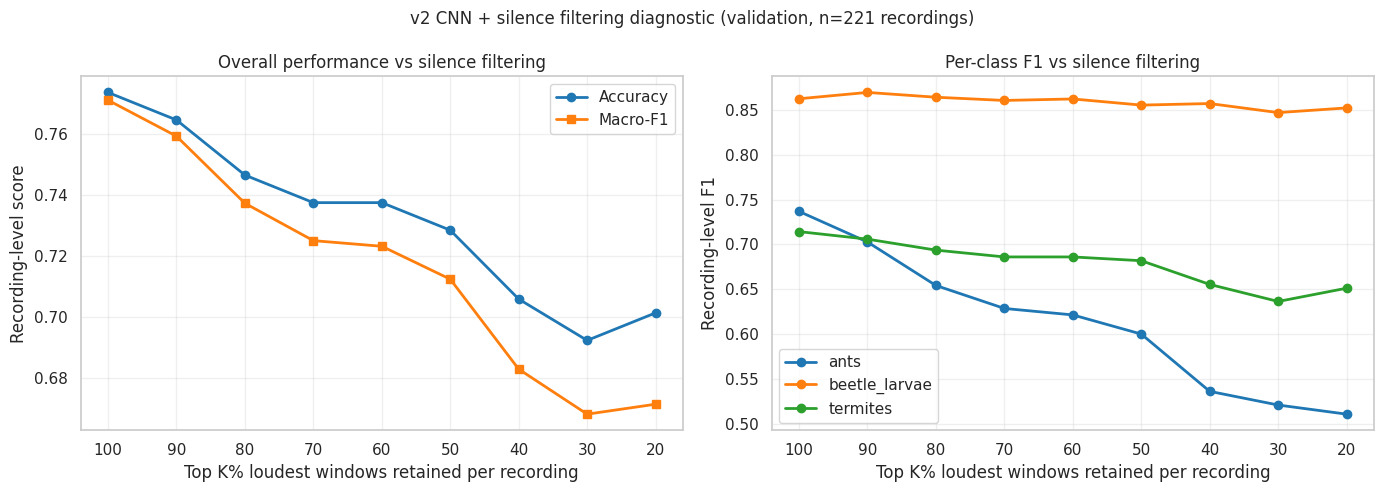

Saved: /content/drive/MyDrive/Invertebrate recordings subset/v2_edgetrim/silence_filtering_sweep_v2.csv

INTERPRETATION
Baseline (K=100%, all windows): macro-F1 = 0.7712
Best K value: 100% → macro-F1 = 0.7712 (Δ = +0.0000)
Worst K value: 30% → macro-F1 = 0.6681 (Δ = -0.1031)

→ Silence filtering DOES NOT IMPROVE performance
  Quiet windows are not systematically miscontributing; averaging works.


In [ ]:
# =============================================================================
# V2 Block 7: Silence-filtering diagnostic
# =============================================================================
print("=" * 70)
print("V2 Block 7: Silence-filtering diagnostic")
print("=" * 70)

# =============================================================================
# Step 1: Load v2 CNN and run inference with mel-energy tracking
# =============================================================================
V2_FROZEN = V2_ROOT / 'cnn_3class_FINAL_v2.pt'
checkpoint = torch.load(V2_FROZEN, map_location=device)
model = SpectrogramCNN(n_classes=3).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded v2 CNN (epoch {checkpoint['epoch']})")

manifest_v2 = pd.read_csv(V2_ROOT / 'features_manifest_v2.csv')
splits_3_v2 = pd.read_csv(V2_ROOT / 'splits_3class_v2.csv')
session_keys = ['day', 'batch', 'taxon', 'count', 'replicate_id']

val_files_v2 = manifest_v2.merge(
    splits_3_v2[splits_3_v2['split'] == 'val'][session_keys],
    on=session_keys, how='inner'
)
print(f"v2 validation files: {len(val_files_v2)}")
print()

# =============================================================================
# Step 2: Per-window inference + mel-energy computation
# =============================================================================
records = []
with torch.no_grad():
    for _, row in tqdm(val_files_v2.iterrows(), total=len(val_files_v2),
                        desc="Inference + energy"):
        data = np.load(V1_FEATURES_DIR / row['feature_filename'])
        features = data['features']  # (n_windows, 128, 235)

        # Compute per-window mean mel-energy
        # Mel values are normalized (~zero-mean); we want the magnitude of
        # deviation from background. Use mean of ABS values as proxy for energy.
        # Alternative: mean of the raw mel values (higher = louder overall).
        # Use mean of raw normalized values — higher means "more energy than average."
        window_energy = features.mean(axis=(1, 2))  # (n_windows,)

        # Model inference
        X = torch.from_numpy(features[:, np.newaxis, :, :].astype(np.float32)).to(device)
        probs = torch.softmax(model(X), dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        for w in range(len(features)):
            records.append({
                'recording_id': row['feature_filename'],
                'window_idx': w,
                'true_label': CLASS_TO_IDX[row['taxon']],
                'pred_label': int(preds[w]),
                'prob_ants': probs[w, 0],
                'prob_beetle_larvae': probs[w, 1],
                'prob_termites': probs[w, 2],
                'mel_energy': float(window_energy[w]),
            })

window_df = pd.DataFrame(records)
print(f"Total v2 validation windows: {len(window_df)}")
print(f"Mel-energy range: [{window_df['mel_energy'].min():.3f}, "
      f"{window_df['mel_energy'].max():.3f}], "
      f"median={window_df['mel_energy'].median():.3f}")
print()

# =============================================================================
# Step 3: Sweep top-K% thresholds
# =============================================================================
print("=" * 70)
print("Step 3: Sweep top-K% mel-energy thresholds")
print("=" * 70)

prob_cols = ['prob_ants', 'prob_beetle_larvae', 'prob_termites']

def aggregate_with_topk(window_df, top_k_pct):
    """Aggregate to recording level using only top K% loudest windows per recording."""
    rows = []
    for rid, g in window_df.groupby('recording_id'):
        g_sorted = g.sort_values('mel_energy', ascending=False)
        n_keep = max(1, int(np.ceil(len(g_sorted) * top_k_pct / 100.0)))
        top_windows = g_sorted.iloc[:n_keep]

        mean_probs = top_windows[prob_cols].mean().values
        rows.append({
            'recording_id': rid,
            'true_label': g['true_label'].iloc[0],
            'pred_label': int(np.argmax(mean_probs)),
            'n_windows_used': n_keep,
            'n_windows_total': len(g_sorted),
        })
    return pd.DataFrame(rows)

thresholds = [100, 90, 80, 70, 60, 50, 40, 30, 20]
sweep_results = []

for k in thresholds:
    rec_df = aggregate_with_topk(window_df, k)
    acc = accuracy_score(rec_df['true_label'], rec_df['pred_label'])
    f1 = f1_score(rec_df['true_label'], rec_df['pred_label'], average='macro')

    # Per-class F1 for the sweep
    prec, rec, f1_pc, _ = precision_recall_fscore_support(
        rec_df['true_label'], rec_df['pred_label'],
        labels=list(range(len(CLASSES_3))), zero_division=0)

    sweep_results.append({
        'top_k_pct': k,
        'accuracy': acc,
        'macro_f1': f1,
        'f1_ants': f1_pc[0],
        'f1_beetle_larvae': f1_pc[1],
        'f1_termites': f1_pc[2],
        'mean_windows_used': rec_df['n_windows_used'].mean(),
    })

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False, float_format='%.4f'))
print()

# =============================================================================
# Step 4: Plot the sweep
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall metrics
ax = axes[0]
ax.plot(sweep_df['top_k_pct'], sweep_df['accuracy'], marker='o', label='Accuracy',
        linewidth=2, color='#1f77b4')
ax.plot(sweep_df['top_k_pct'], sweep_df['macro_f1'], marker='s', label='Macro-F1',
        linewidth=2, color='#ff7f0e')
ax.set_xlabel('Top K% loudest windows retained per recording')
ax.set_ylabel('Recording-level score')
ax.set_title('Overall performance vs silence filtering')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # 100% (all) on left, most aggressive filtering on right

# Per-class F1
ax = axes[1]
for cls, color in zip(CLASSES_3, ['#1f77b4', '#ff7f0e', '#2ca02c']):
    ax.plot(sweep_df['top_k_pct'], sweep_df[f'f1_{cls}'],
            marker='o', label=cls, linewidth=2, color=color)
ax.set_xlabel('Top K% loudest windows retained per recording')
ax.set_ylabel('Recording-level F1')
ax.set_title('Per-class F1 vs silence filtering')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

fig.suptitle(f'v2 CNN + silence filtering diagnostic (validation, n=221 recordings)',
             fontsize=12)
plt.tight_layout()
save_v2_figure(fig, 'silence_filtering_sweep_v2', subdir='figures')
plt.show()
plt.close(fig)

# =============================================================================
# Step 5: Save and interpret
# =============================================================================
sweep_df.to_csv(V2_ROOT / 'silence_filtering_sweep_v2.csv', index=False)
print(f"Saved: {V2_ROOT / 'silence_filtering_sweep_v2.csv'}")
print()

# Interpretation
baseline_f1 = sweep_df[sweep_df['top_k_pct'] == 100]['macro_f1'].values[0]
best_row = sweep_df.loc[sweep_df['macro_f1'].idxmax()]
worst_row = sweep_df.loc[sweep_df['macro_f1'].idxmin()]

print("=" * 70)
print("INTERPRETATION")
print("=" * 70)
print(f"Baseline (K=100%, all windows): macro-F1 = {baseline_f1:.4f}")
print(f"Best K value: {int(best_row['top_k_pct'])}% → macro-F1 = {best_row['macro_f1']:.4f}"
      f" (Δ = {best_row['macro_f1'] - baseline_f1:+.4f})")
print(f"Worst K value: {int(worst_row['top_k_pct'])}% → macro-F1 = {worst_row['macro_f1']:.4f}"
      f" (Δ = {worst_row['macro_f1'] - baseline_f1:+.4f})")
print()

delta_best = best_row['macro_f1'] - baseline_f1
if delta_best > 0.02:
    print("→ Silence filtering MEANINGFULLY IMPROVES performance")
    print(f"  Best K: {int(best_row['top_k_pct'])}%. Consider investing in a more")
    print(f"  principled activity-detection method (learned classifier, etc.).")
elif delta_best > 0:
    print("→ Silence filtering provides MARGINAL improvement")
    print(f"  Best K: {int(best_row['top_k_pct'])}%, gain +{delta_best:.3f} macro-F1.")
    print(f"  Probably not worth pursuing further as a permanent methodology.")
else:
    print("→ Silence filtering DOES NOT IMPROVE performance")
    print("  Quiet windows are not systematically miscontributing; averaging works.")